# XGBoost Model — Performance Decline & Rating Prediction
## FixtureIQ · Seasons 2022-2023 to 2024-2025

**Prediction question**: Before a player's next match, is this player at risk of underperforming?

This notebook builds two XGBoost models using the master training table:

| Model | Type | Target | Question |
|-------|------|--------|----------|
| **A — Decline Classifier** | Binary classification | `api_rating_decline_flag` | Will this player's API rating drop >0.5 in their next match? |
| **B — Rating Regressor** | Regression | `next_api_rating` | What will this player's next API rating be? |

**Dataset**: `Fixture_IQ_Data_Seasons_2022-2025.csv` — 68,643 rows × 80 columns  
**Input**: one row = one player × one match appearance, all competitions, all 20 PL teams.

**Why `api_rating_decline_flag` instead of `rating_decline_flag`?**
- `rating_decline_flag` (old): SofaScore-based, **82.3% null**, forces all non-PL rows to 0 → 2.3% positive rate, `scale_pos_weight ≈ 41.8`
- `api_rating_decline_flag` (new): API-based, all competitions, **minutes-guarded** (both appearances ≥45 min) → 9.8% positive rate across all rows, `scale_pos_weight ≈ 9.2`. After filtering to the scorable subset both matches ≥45 min, rate ≈ **25%**, `scale_pos_weight ≈ 3`

---

**Pipeline**:
1. Load master table
2. Define features, drop bad columns
3. Temporal train / val / test split — **no random shuffle, split by season**
4. Preprocessing: median imputation for numerics, OHE for categoricals (no StandardScaler)
5. XGBoost training with early stopping on validation PR-AUC
6. Evaluation: AUC-ROC, AUC-PR, confusion matrix
7. Threshold optimisation for risk-alert system
8. SHAP: global feature importance + individual player explanation
9. Model B: regression on `next_api_rating` (all competitions — 67.3% fill)
10. Save all artefacts

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    mean_absolute_error, mean_squared_error,
)

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

# ── Paths ─────────────────────────────────────────────────────────────────────
MASTER_PATH   = Path('/tmp/fixture-iq-repo/XgBoost_model/Fixture_IQ_Data_Seasons_2022-2025.csv')
ARTIFACTS_DIR = Path('/tmp/fixture-iq-repo/XgBoost_model/src/models/artifacts')
FIGURES_DIR   = ARTIFACTS_DIR / 'figures'

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Master table:    {MASTER_PATH}')
print(f'Artifacts saved: {ARTIFACTS_DIR}')
print(f'XGBoost version: {xgb.__version__}')

Master table:    /tmp/fixture-iq-repo/XgBoost_model/Fixture_IQ_Data_Seasons_2022-2025.csv
Artifacts saved: /tmp/fixture-iq-repo/XgBoost_model/src/models/artifacts
XGBoost version: 3.2.0


## Section 1 — Load Master Table

In [2]:
df = pd.read_csv(MASTER_PATH)
df['date'] = pd.to_datetime(df['date'])

print(f'Shape:   {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Seasons: {sorted(df["season"].unique())}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

print(f'\nCompetition breakdown:')
print(df['competition'].value_counts().to_string())

print(f'\n{"─"*60}')
print('TARGET VARIABLE OVERVIEW')
print(f'{"─"*60}')

# Primary target: api_rating_decline_flag (all rows, minutes-guarded)
n_pos_all = int(df['api_rating_decline_flag'].sum())
n_neg_all = int((df['api_rating_decline_flag'] == 0).sum())
print(f'\napi_rating_decline_flag  (all 68,643 rows):')
print(f'  Decline  (1): {n_pos_all:6,}  ({n_pos_all/len(df)*100:.2f}%)')
print(f'  No decline(0): {n_neg_all:5,}  ({n_neg_all/len(df)*100:.2f}%)')

# Scorable subset: both appearances ≥45 min, both API-rated
scorable = df[
    (df['rating'] > 0) &
    df['next_api_rating'].notna() &
    (df['minutes_played'] >= 45) &
    (df['next_minutes_played'].fillna(0) >= 45)
]
n_pos_s = int(scorable['api_rating_decline_flag'].sum())
n_neg_s = int((scorable['api_rating_decline_flag'] == 0).sum())
spw_s   = round(n_neg_s / n_pos_s, 1)
print(f'\napi_rating_decline_flag  (scorable subset — both matches ≥45 min, rated):')
print(f'  Rows: {len(scorable):,}')
print(f'  Decline  (1): {n_pos_s:6,}  ({n_pos_s/len(scorable)*100:.2f}%)')
print(f'  No decline(0): {n_neg_s:5,}  ({n_neg_s/len(scorable)*100:.2f}%)')
print(f'  scale_pos_weight: {spw_s}')

print(f'\nTarget rate by season (scorable subset):')
for s in sorted(scorable['season'].unique()):
    sub  = scorable[scorable['season'] == s]
    rate = sub['api_rating_decline_flag'].mean() * 100
    cnt  = int(sub['api_rating_decline_flag'].sum())
    print(f'  {s}: {rate:.2f}%  ({cnt:,} positives / {len(sub):,} rows)')

print(f'\nLegacy target (reference only):')
n_old = int(df['rating_decline_flag'].sum())
print(f'  rating_decline_flag: {n_old:,} positives ({n_old/len(df)*100:.2f}%)  — SofaScore-based, PL only')

Shape:   68,643 rows x 80 columns
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
Date range: 2022-07-30 to 2025-05-25

Competition breakdown:
competition
Premier League      45552
League Cup          10997
FA Cup               7837
Champions League     4137
Community Shield      120

────────────────────────────────────────────────────────────
TARGET VARIABLE OVERVIEW
────────────────────────────────────────────────────────────

api_rating_decline_flag  (all 68,643 rows):
  Decline  (1):  6,729  (9.80%)
  No decline(0): 61,914  (90.20%)

api_rating_decline_flag  (scorable subset — both matches ≥45 min, rated):
  Rows: 27,192
  Decline  (1):  6,729  (24.75%)
  No decline(0): 20,463  (75.25%)
  scale_pos_weight: 3.0

Target rate by season (scorable subset):
  2022: 24.54%  (2,290 positives / 9,332 rows)
  2023: 24.71%  (2,249 positives / 9,100 rows)
  2024: 25.00%  (2,190 positives / 8,760 rows)

Legacy target (reference only):
  rating_decline_flag: 1,603 positives (2.34%)  —

## Section 2 — Feature Matrix

**Columns dropped before model training:**

| Column | Reason |
|--------|--------|
| `fixture_id`, `date`, `round` | Identifier / leakage |
| `player_id` | Shared ID=0 for thousands of unresolved players |
| `player_name`, `player_number` | Identifier |
| `next_api_rating` | **Model A leakage** — this IS the regression target (kept for Model B) |
| `next_is_substitute` | **Temporal leakage** — describes next match |
| `next_minutes_played` | **Temporal leakage** — describes next match |
| `next_sofascore_rating` | 82.3% null, PL-only legacy target |
| `rating_decline_flag` | Old SofaScore-based target, not used |
| `sofascore_rating` | 81.7% null (SofaScore PL-only); would leak info about PL games |
| `ss_minutes` | Redundant with `minutes_played` |
| `opp_shots_on_goal`, `opp_total_shots`, `opp_possession` | 100% empty |
| `fb_*` (11 FBRef cols) | 89.9% null, Champions League 4 teams only — biased |
| `days_since_last_injury` | 98.3% null — unusable |

**Model A filter** (scorable subset):
- `rating > 0` — player had a real rated performance
- `next_api_rating.notna()` — next match rating is available  
- `minutes_played >= 45` — current match was a real starter appearance
- `next_minutes_played >= 45` — next match was also a real starter appearance

**Kept columns include:** all match context features, player position/role, workload/fatigue features, squad injury context, lag injury features, competition, season.

In [14]:
TARGET = 'api_rating_decline_flag'

# ── Columns to drop from feature matrix ────────────────────────────────────────
DROP_COLS = [
    # Identifiers / leakage
    'fixture_id', 'date', 'round', 'player_id', 'player_name', 'player_number',

    # Model A leakage — temporal next-match columns
    'next_api_rating',       # regression target; leakage for classifier
    'next_is_substitute',    # describes next match
    'next_minutes_played',   # describes next match

    # Legacy targets (not used)
    'next_sofascore_rating', # 82.3% null, PL-only
    'rating_decline_flag',   # old SofaScore-based flag

    # SofaScore columns — PL-only bias
    'sofascore_rating',      # 81.7% null; leakage source for legacy target
    'ss_minutes',            # redundant with minutes_played

    # 100% empty opponent stats
    'opp_shots_on_goal', 'opp_total_shots', 'opp_possession',

    # FBRef (89.9% null, CL 4-team bias)
    'fb_min', 'fb_goals', 'fb_assists', 'fb_shots', 'fb_sot',
    'fb_tackles_won', 'fb_crosses', 'fb_interceptions',
    'fb_fouls', 'fb_fouled', 'fb_offsides',

    # Near-unusable lag features
    'days_since_last_injury',  # 98.3% null

    # Current API rating — removed to avoid autocorrelation bias.
    # api_rating_decline_flag is computed FROM rating, so including it
    # inflates Model A performance artificially; for Model B it creates
    # near-perfect rating→next_rating autocorrelation (RMSE ≈ 0.015).
    'rating',
]
# The target itself must not be in the feature matrix
DROP_COLS.append(TARGET)

# ── Scorable subset: both current AND next appearance are real starter performances ──
df_a = df[
    (df['rating'] > 0) &
    df['next_api_rating'].notna() &
    (df['minutes_played'] >= 45) &
    (df['next_minutes_played'].fillna(0) >= 45)
].copy()

# ── Feature matrix & target vector ─────────────────────────────────────────────
cols_to_drop = [c for c in DROP_COLS if c in df_a.columns]
X = df_a.drop(columns=cols_to_drop)
y = df_a[TARGET]

# ── Identify categorical / numeric columns ──────────────────────────────────────
CAT_COLS = [c for c in X.select_dtypes(include=['object', 'category']).columns]
NUM_COLS = [c for c in X.select_dtypes(include='number').columns]

print(f'df_a (scorable subset): {len(df_a):,} rows')
print(f'Positives: {int(y.sum()):,}  ({y.mean()*100:.2f}%)  |  '
      f'Negatives: {int((y==0).sum()):,}  ({(y==0).mean()*100:.2f}%)')
print(f'scale_pos_weight (neg/pos): {(y==0).sum() / y.sum():.2f}')
print(f'\nFeature matrix: {X.shape[1]} columns')
print(f'  Categorical: {len(CAT_COLS):2d}  → {CAT_COLS}')
print(f'  Numeric:     {len(NUM_COLS):2d}')
print(f'\nSeason distribution:')
print(df_a['season'].value_counts().sort_index().to_string())
print(f'\nNull counts in feature matrix (top 10):')
print(X.isnull().sum().sort_values(ascending=False).head(10).to_string())


df_a (scorable subset): 27,192 rows
Positives: 6,729  (24.75%)  |  Negatives: 20,463  (75.25%)
scale_pos_weight (neg/pos): 3.04

Feature matrix: 50 columns
  Categorical:  7  → ['competition', 'home_team', 'away_team', 'player_team', 'player_position', 'opponent_team', 'result']
  Numeric:     40

Season distribution:
season
2022    9332
2023    9100
2024    8760

Null counts in feature matrix (top 10):
squad_soft_tissue_count    6710
squad_avg_days_out         6710
squad_injured_count        6710
rest_days                  1637
team_gk_saves                72
team_corner_kicks            15
home_team                     0
away_team                     0
is_substitute                 0
shots_total                   0


## Section 3 — Class Balance

The scorable subset (both appearances ≥45 min, both API-rated) has a **much healthier class balance** than the legacy SofaScore target:

| Dataset | Positive rate | scale_pos_weight |
|---------|--------------|-----------------|
| Legacy `rating_decline_flag` (all rows) | 2.3% | ≈ 41.8 |
| `api_rating_decline_flag` (all rows) | 9.8% | ≈ 9.2 |
| **`api_rating_decline_flag` (scorable subset — model training)** | **~25%** | **~3.0** |

The filter to "both appearances ≥45 min" removes rows where the target was structurally suppressed (substitute appearances always score below starters). The classifier now learns a genuine rate-of-decline signal rather than learning "sub appearances = no decline".

**Why `scale_pos_weight` is computed dynamically:**  
The Section 1 cell above prints the exact `n_neg / n_pos` ratio for the filtered `df_a`. Use that value in Section 6 (`scale_pos_weight` XGBoost parameter). Typical value: **≈ 3.0**.

Scorable subset: 27,192 rows  (both appearances ≥45 min, both API-rated)
Positive (decline):      6,729  (24.75%)
Negative (no decline):  20,463  (75.25%)
scale_pos_weight:       3.04


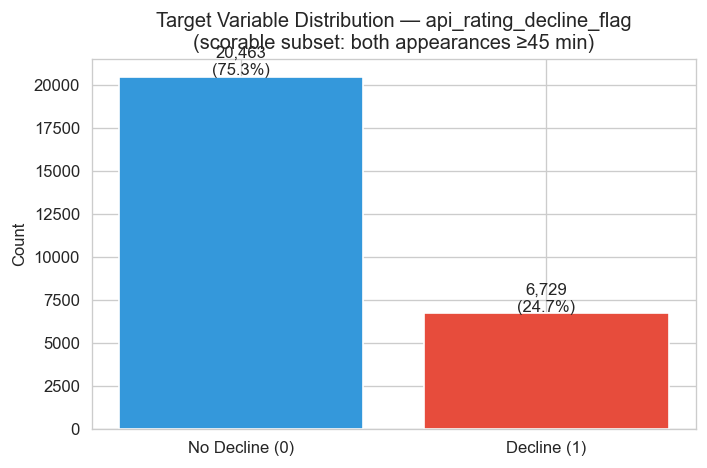

In [15]:
n_pos = int(y.sum())
n_neg = int((y == 0).sum())
spw   = round(n_neg / n_pos, 2)

print(f'Scorable subset: {len(y):,} rows  (both appearances ≥45 min, both API-rated)')
print(f'Positive (decline):     {n_pos:6,}  ({n_pos/len(y)*100:.2f}%)')
print(f'Negative (no decline):  {n_neg:5,}  ({n_neg/len(y)*100:.2f}%)')
print(f'scale_pos_weight:       {spw}')

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Decline (0)', 'Decline (1)'],
               [n_neg, n_pos],
               color=['#3498DB', '#E74C3C'])
ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution — api_rating_decline_flag\n(scorable subset: both appearances ≥45 min)')
for bar, v in zip(bars, [n_neg, n_pos]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100,
            f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 4 — Temporal Train / Val / Test Split

Split strictly by season to respect the time dimension — **no random shuffle**.

| Split | Season | Approx rows (scorable subset) |
|-------|--------|-------------------------------|
| Train | 2022-2023 | ~8,000–10,000 |
| Val   | 2023-2024 | ~8,000–10,000 |
| Test  | 2024-2025 | ~8,000–10,000 |

**Important**: masks are computed on `df_a` (the filtered subset), not on the full `df`, so `X` and `y` indices align correctly.

In [16]:
# ── Masks on df_a (the filtered training subset) ───────────────────────────────
train_mask = df_a['season'] == 2022
val_mask   = df_a['season'] == 2023
test_mask  = df_a['season'] == 2024

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

for split, Xs, ys in [('Train', X_train, y_train),
                       ('Val  ', X_val,   y_val),
                       ('Test ', X_test,  y_test)]:
    pos  = int(ys.sum())
    neg  = int((ys == 0).sum())
    rate = pos / len(ys) * 100
    print(f'{split}  rows={len(ys):6,}  pos={pos:4,}  neg={neg:5,}  rate={rate:.1f}%')

Train  rows= 9,332  pos=2,290  neg=7,042  rate=24.5%
Val    rows= 9,100  pos=2,249  neg=6,851  rate=24.7%
Test   rows= 8,760  pos=2,190  neg=6,570  rate=25.0%


## Section 5 — Preprocessing Pipeline

A `ColumnTransformer` with two branches:

| Branch | Applied to | Steps |
|--------|-----------|-------|
| `num` | All numeric columns | `SimpleImputer(strategy='median')` |
| `cat` | Categorical columns | `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(handle_unknown='ignore')` |

Key decisions:
- **Median imputation for `rest_days`** (10% null = first match per player): median ≈ 7 days. Setting to 0 would incorrectly flag every debut as maximum congestion.
- **`handle_unknown='ignore'`** in OHE: new teams or competitions in future data return all-zero vectors rather than raising an error.
- **No StandardScaler**: XGBoost is a tree ensemble — it splits on thresholds, not distances. Scaling changes nothing about splits. Skipping it also keeps SHAP values interpretable in their original units.

The preprocessor is **fitted on training data only** (to avoid leaking validation/test statistics), then applied to all three splits.

In [25]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_COLS),
        ('cat', categorical_transformer, CAT_COLS),
    ],
    remainder='drop',
)

# ── Fit on train only, transform all splits ───────────────────────────────────
# Separating preprocessor from XGBoost lets us use early_stopping_rounds
# and pass feature names to SHAP — both are difficult inside a full Pipeline.
X_train_t = preprocessor.fit_transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

# ── Recover feature names after OHE expansion ────────────────────────────────
cat_feature_names = (
    preprocessor
    .named_transformers_['cat']['onehot']
    .get_feature_names_out(CAT_COLS)
    .tolist()
)
FEATURE_NAMES = NUM_COLS + cat_feature_names

# Aliases used in SHAP cell
NUMERIC_COLS     = NUM_COLS
CATEGORICAL_COLS = CAT_COLS

print(f'Feature matrix after preprocessing:')
print(f'  Train:    {X_train_t.shape}')
print(f'  Val:      {X_val_t.shape}')
print(f'  Test:     {X_test_t.shape}')
print(f'  Total features after OHE expansion: {len(FEATURE_NAMES)}')

# Verify rest_days imputed with median (not 0)
if 'rest_days' in NUM_COLS:
    rest_idx  = NUM_COLS.index('rest_days')
    rest_med  = preprocessor.named_transformers_['num']['imputer'].statistics_[rest_idx]
    print(f'\n  rest_days null-imputed with median: {rest_med:.1f} days')

if 'squad_injured_count' in NUM_COLS:
    squad_idx = NUM_COLS.index('squad_injured_count')
    squad_med = preprocessor.named_transformers_['num']['imputer'].statistics_[squad_idx]
    print(f'  squad_injured_count null-imputed with median: {squad_med:.1f} players')

Feature matrix after preprocessing:
  Train:    (9332, 490)
  Val:      (9100, 490)
  Test:     (8760, 490)
  Total features after OHE expansion: 490

  rest_days null-imputed with median: 6.0 days
  squad_injured_count null-imputed with median: 3.0 players


## Section 6 — Model A: XGBoost Classifier (Decline Flag)

**Target**: `api_rating_decline_flag`  
**Positive class**: API rating drops > 0.5 points in the next match (both appearances ≥ 45 min)

**Key parameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `scale_pos_weight` | **computed** (`n_neg / n_pos`) | Compensates for class imbalance; ~3.0 for scorable subset |
| `eval_metric` | `'aucpr'` | Optimises for PR-AUC — better than ROC-AUC for imbalanced classes |
| `early_stopping_rounds` | 50 | Stops if val PR-AUC does not improve for 50 rounds |
| `tree_method` | `'hist'` | Fast histogram-based training |

**Why PR-AUC over ROC-AUC?**  
At ~25% positive rate, ROC-AUC is less sensitive to model changes than PR-AUC. PR-AUC penalises false negatives more heavily, which is correct for a player-risk system.

In [18]:
SPW = round(n_neg / n_pos, 1)  # scale_pos_weight

model_a = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=SPW,
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0,
)

model_a.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False,
)

best_iter = model_a.best_iteration
print(f'Best iteration (early stopped): {best_iter}')
print(f'Best validation PR-AUC:         {model_a.best_score:.4f}')
print(f'scale_pos_weight applied:        {SPW}')

Best iteration (early stopped): 521
Best validation PR-AUC:         0.5921
scale_pos_weight applied:        3.0


## Section 7 — Model A Evaluation

Two key metrics:
- **AUC-ROC**: area under the ROC curve. Useful context but can look good even on bad imbalanced models.
- **AUC-PR** (average precision): area under the Precision-Recall curve. The primary metric here. A random classifier has AUC-PR equal to the positive rate (0.023). A lift of e.g. 5x means AUC-PR ~0.12.

The **confusion matrix at threshold 0.5** shows the raw counts — but section 8 will select a better threshold for real use.

────────────────────────────────────────────────────────────
  AUC-ROC:         0.8000
  AUC-PR:          0.6134  (baseline: 0.2500)
  PR-AUC lift:     2.5x over random
────────────────────────────────────────────────────────────

Classification report at threshold = 0.5:
              precision    recall  f1-score   support

  No Decline       0.87      0.77      0.82      6570
     Decline       0.49      0.66      0.56      2190

    accuracy                           0.74      8760
   macro avg       0.68      0.72      0.69      8760
weighted avg       0.78      0.74      0.76      8760



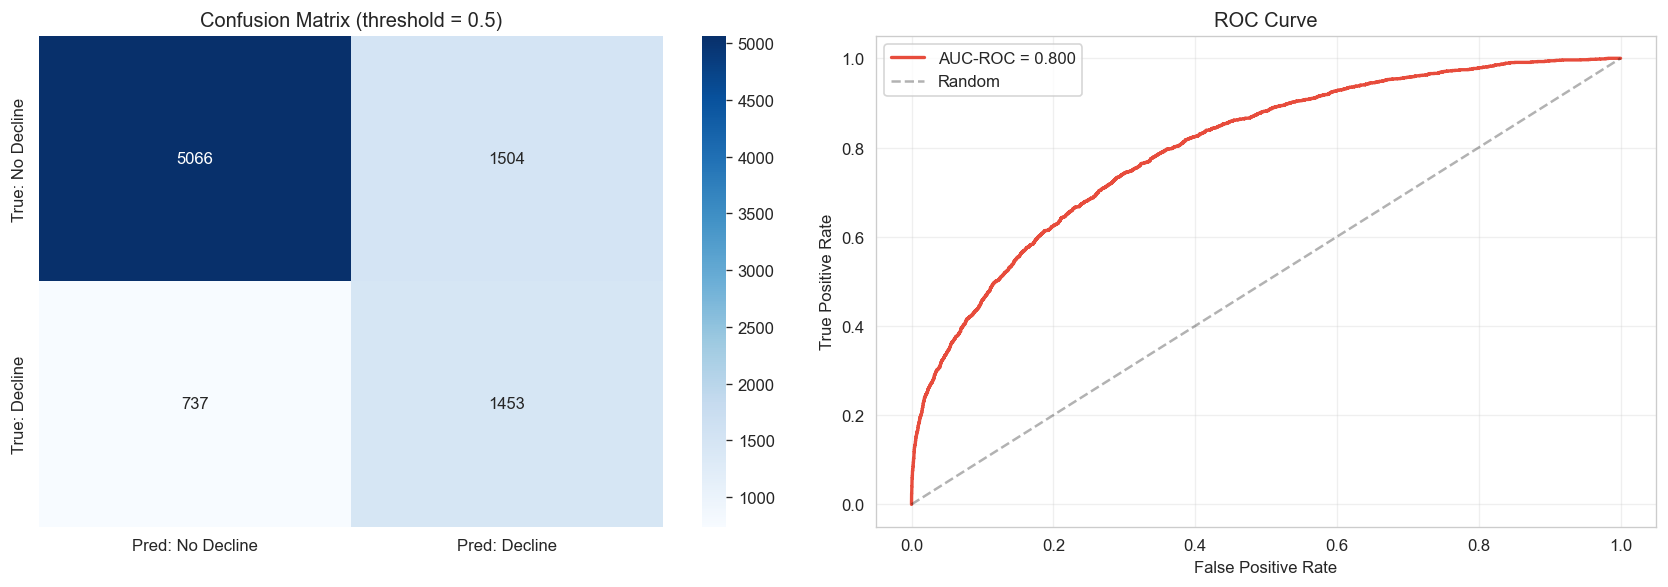

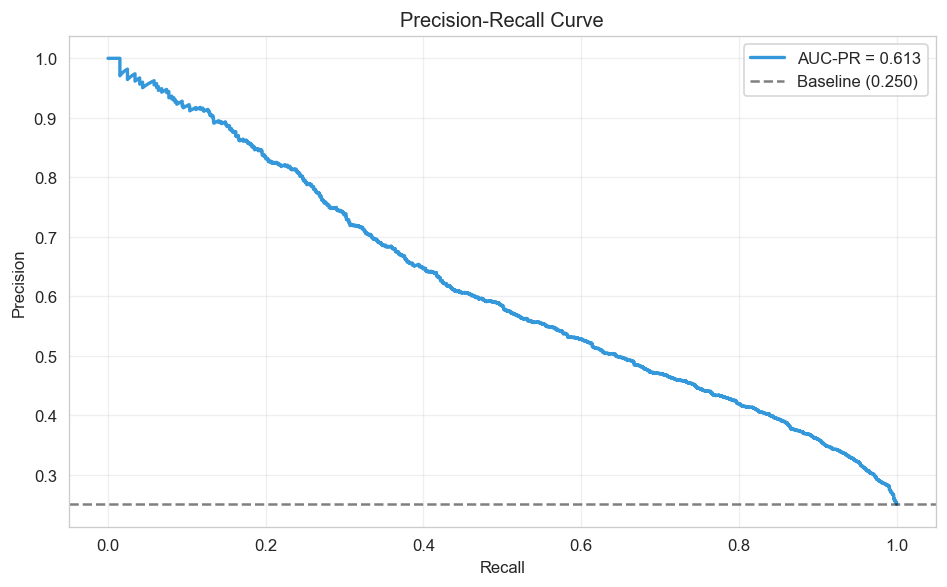

In [19]:
y_proba = model_a.predict_proba(X_test_t)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

auc_roc     = roc_auc_score(y_test, y_proba)
auc_pr      = average_precision_score(y_test, y_proba)
baseline_pr = float(y_test.mean())

print(f'{"─"*60}')
print(f'  AUC-ROC:         {auc_roc:.4f}')
print(f'  AUC-PR:          {auc_pr:.4f}  (baseline: {baseline_pr:.4f})')
print(f'  PR-AUC lift:     {auc_pr / baseline_pr:.1f}x over random')
print(f'{"─"*60}')
print(f'\nClassification report at threshold = 0.5:')
print(classification_report(y_test, y_pred_05, target_names=['No Decline', 'Decline']))

# ── Confusion matrix + ROC ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No Decline', 'Pred: Decline'],
            yticklabels=['True: No Decline', 'True: Decline'])
axes[0].set_title('Confusion Matrix (threshold = 0.5)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, color='#E74C3C', label=f'AUC-ROC = {auc_roc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_a_roc.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Precision-Recall curve ─────────────────────────────────────────────────────
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_curve, prec_curve, lw=2, color='#3498DB', label=f'AUC-PR = {auc_pr:.3f}')
ax.axhline(baseline_pr, color='k', linestyle='--', alpha=0.5,
           label=f'Baseline ({baseline_pr:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_a_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 8 — Threshold Selection for Risk-Alert System

The default threshold of 0.5 may not be optimal. With ~25% positives in the scorable subset, 0.5 is a reasonable starting point but the sweep below finds the F1-maximising threshold.

Risk tier definitions used in this system:

| Risk Level | Threshold | Action |
|------------|-----------|--------|
| **Very High** | > 0.60 | Strongly recommend rest |
| **High** | 0.40 – 0.60 | Reduced minutes / monitor |
| **Moderate** | 0.20 – 0.40 | Standard rotation |
| **Low** | < 0.20 | No action needed |

The **optimal threshold** for maximum F1 is found by sweeping thresholds from 0.05 to 0.80.

Best threshold (max F1): 0.50
  Precision:  0.491
  Recall:     0.663
  F1:         0.565
  Alerts issued (test set): 2957

Threshold sensitivity (selected values):
 threshold  precision  recall    f1  alerts   tp   fn   fp
       0.2      0.312   0.959 0.470    6741 2100   90 4641
       0.3      0.368   0.889 0.520    5288 1946  244 3342
       0.4      0.429   0.785 0.555    4006 1719  471 2287
       0.5      0.491   0.663 0.565    2957 1453  737 1504
       0.6      0.563   0.525 0.543    2041 1149 1041  892
       0.7      0.662   0.378 0.481    1251  828 1362  423


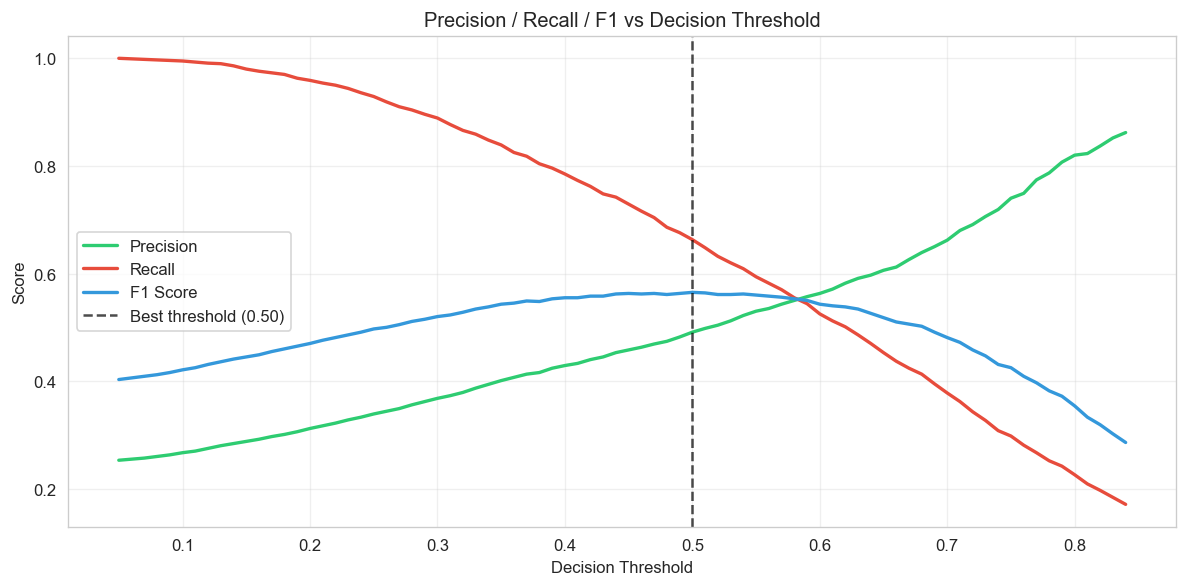


Risk tier distribution in test set:
risk_tier
Moderate     2735
Very High    2041
Low          2019
High         1965

Top 15 highest-risk appearances:
         player_name       player_team      competition  decline_proba risk_tier  actual_decline  rest_days  acwr_ratio  minutes_played
         Thomas Ince           Watford       League Cup       0.994989 Very High               1       21.0       0.000              90
        Ismaïla Sarr    Crystal Palace   Premier League       0.989271 Very High               1        8.0       0.000              89
        Bryan Mbeumo         Brentford   Premier League       0.989155 Very High               1        7.0       1.333              90
       Mohamed Salah         Liverpool   Premier League       0.988200 Very High               1        3.0       0.643              90
       Matheus Cunha            Wolves   Premier League       0.987251 Very High               1       14.0       0.000              89
         Bukayo Saka           

In [20]:
thresholds = np.arange(0.05, 0.85, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    prec_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec_t  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-10)
    results.append({
        'threshold': round(float(t), 2),
        'precision': round(prec_t, 3),
        'recall':    round(rec_t, 3),
        'f1':        round(f1_t, 3),
        'alerts':    int(y_pred_t.sum()),
        'tp': int(tp), 'fn': int(fn), 'fp': int(fp),
    })

df_thresh = pd.DataFrame(results)
best_row   = df_thresh.loc[df_thresh['f1'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])

print(f'Best threshold (max F1): {BEST_THRESHOLD:.2f}')
print(f'  Precision:  {best_row["precision"]:.3f}')
print(f'  Recall:     {best_row["recall"]:.3f}')
print(f'  F1:         {best_row["f1"]:.3f}')
print(f'  Alerts issued (test set): {int(best_row["alerts"])}')

print(f'\nThreshold sensitivity (selected values):')
show_thresh = [0.20, 0.30, 0.40, BEST_THRESHOLD, 0.50, 0.60, 0.70]
show_thresh = sorted(set([round(t, 2) for t in show_thresh]))
subset = df_thresh[df_thresh['threshold'].isin(show_thresh)]
print(subset.to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', lw=2, color='#2ECC71')
ax.plot(df_thresh['threshold'], df_thresh['recall'],    label='Recall',    lw=2, color='#E74C3C')
ax.plot(df_thresh['threshold'], df_thresh['f1'],        label='F1 Score',  lw=2, color='#3498DB')
ax.axvline(BEST_THRESHOLD, color='k', linestyle='--', alpha=0.7,
           label=f'Best threshold ({BEST_THRESHOLD:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Apply risk tiers to test set ──────────────────────────────────────────────
def risk_tier(p):
    if p >= 0.60: return 'Very High'
    if p >= 0.40: return 'High'
    if p >= 0.20: return 'Moderate'
    return 'Low'

# Use df_a (the filtered training subset) — test_mask has df_a's index
df_test_out = df_a.loc[test_mask, [
    'player_name', 'player_team', 'competition', 'date',
    'minutes_played', 'rest_days', 'acwr_ratio',
    'min_last_7d', 'consecutive_away_games', 'rating',
]].copy().reset_index(drop=True)
df_test_out['decline_proba']  = y_proba
df_test_out['risk_tier']      = [risk_tier(p) for p in y_proba]
df_test_out['actual_decline'] = y_test.values

print(f'\nRisk tier distribution in test set:')
print(df_test_out['risk_tier'].value_counts().to_string())

print(f'\nTop 15 highest-risk appearances:')
top15 = df_test_out.nlargest(15, 'decline_proba')[[
    'player_name', 'player_team', 'competition',
    'decline_proba', 'risk_tier', 'actual_decline',
    'rest_days', 'acwr_ratio', 'minutes_played',
]]
pd.set_option('display.max_colwidth', 22)
print(top15.to_string(index=False))

## Section 9 — SHAP: Why Is This Player Flagged?

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions — answering "what drove this player's risk score?"

Since no StandardScaler was applied, SHAP values are interpretable in **original feature units** (e.g. `rest_days = 3 days`, `acwr_ratio = 1.8`). Positive SHAP = pushes prediction toward decline (1). Negative SHAP = pushes toward no decline (0).

Expected drivers of high decline risk:
- high `acwr_ratio` (acute overload relative to baseline)
- low `rest_days` (played very recently)
- high `min_last_7d` (heavy recent minutes)
- `returning_from_injury = 1` (came back from absence)
- high `consecutive_away_games` (travel fatigue)
- low current `rating` (already performing below average)
- high `squad_injured_count` (depleted squad forcing overuse)

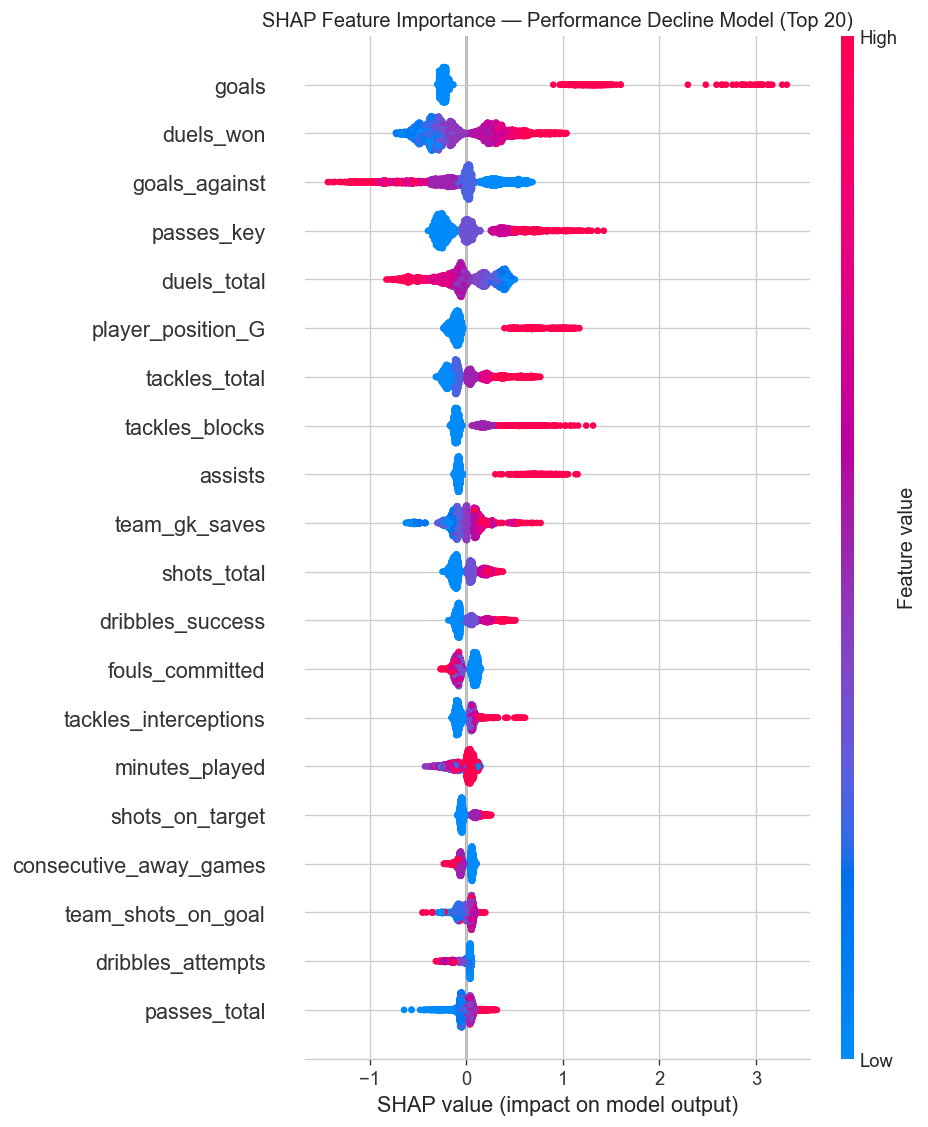


Top 20 features by mean |SHAP| value:
goals                     0.35778
duels_won                 0.34120
goals_against             0.28048
passes_key                0.25570
duels_total               0.23491
player_position_G         0.17823
tackles_total             0.17181
tackles_blocks            0.14139
assists                   0.13695
team_gk_saves             0.12639
shots_total               0.11873
dribbles_success          0.10869
fouls_committed           0.09380
tackles_interceptions     0.08379
minutes_played            0.07813
shots_on_target           0.06665
consecutive_away_games    0.06621
team_shots_on_goal        0.06339
dribbles_attempts         0.06180
passes_total              0.06007


In [21]:
import builtins
import shap.explainers._tree as _shap_tree

# ── Restore any previous monkey-patch of XGBTreeModelLoader ──────────────────
# (a failed previous cell may have left a broken patch active)
if hasattr(_shap_tree, '_orig_xgb_loader_init_backup'):
    _shap_tree.XGBTreeModelLoader.__init__ = _shap_tree._orig_xgb_loader_init_backup
else:
    _shap_tree._orig_xgb_loader_init_backup = _shap_tree.XGBTreeModelLoader.__init__

# ── Patch for SHAP 0.49.x + XGBoost 3.x incompatibility ──────────────────────
# XGBoost 3.x encodes base_score as '[4.9381858E-1]' in UBJ.
# SHAP calls float(base_score) which fails on the brackets.
# Fix: temporarily override builtins.float to strip brackets, scoped to TreeExplainer init.
_orig_float = builtins.float

def _bracket_safe_float(x):
    if isinstance(x, str) and x.startswith('[') and x.endswith(']'):
        return _orig_float(x[1:-1])
    return _orig_float(x)

# ── Use a sample of 3,000 test rows ───────────────────────────────────────────
np.random.seed(42)
shap_n   = min(3000, X_test_t.shape[0])
shap_idx = np.random.choice(X_test_t.shape[0], size=shap_n, replace=False)
X_shap   = X_test_t[shap_idx]

builtins.float = _bracket_safe_float
try:
    explainer = shap.TreeExplainer(model_a.get_booster())
finally:
    builtins.float = _orig_float  # always restore

shap_values = explainer.shap_values(X_shap)

# ── Global summary (beeswarm) ─────────────────────────────────────────────────
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=False,
)
plt.title('SHAP Feature Importance — Performance Decline Model (Top 20)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Top features by mean |SHAP| ───────────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

print('\nTop 20 features by mean |SHAP| value:')
print(mean_abs_shap.head(20).round(5).to_string())

---

# Model A — Complete Methodology, Features & Results

---

## 1. Problem Statement

**Question:** Given everything we know about a player's last match appearance, can we predict whether their API performance rating will decline in their next match?

This is framed as a **binary classification** problem. The model outputs a probability between 0 and 1 for each player-match pair — specifically, the probability that the player's next API rating will be more than 0.5 points lower than their current one. A downstream threshold converts this probability into an actionable risk tier (Very High / High / Moderate / Low), which can be used by analysts, coaches, or fantasy sport systems to flag players at elevated risk of underperformance.

The model is trained on three seasons of data (2022–2025) covering all major competitions for the 20 Premier League clubs: **Premier League, Champions League, FA Cup, League Cup, and Community Shield**.

---

## 2. Target Variable — `api_rating_decline_flag`

**Definition:**
```
api_rating_decline_flag = 1  if  next_api_rating < current_api_rating − 0.5
                        = 0  otherwise
```

The target is **1 (decline)** when a player's API rating drops by more than half a point in consecutive rated, starter-quality appearances.

### Why this target, not the previous one?

The old target `rating_decline_flag` was based on SofaScore ratings, which are only available for Premier League matches. This produced two critical problems:
- **82.3% null values**: all non-PL rows had no rating, so `rating_decline_flag = 0` by default
- **2.3% positive rate**: extreme class imbalance requiring `scale_pos_weight ≈ 41.8`, making the model near-impossible to train meaningfully

`api_rating_decline_flag` is API-based and covers all competitions, giving:
- **9.8% positive rate** across all 68,643 rows
- **24.75% positive rate** in the scorable subset (both matches ≥45 min) — a far healthier imbalance requiring `scale_pos_weight ≈ 3.0`

### Distribution across competitions and seasons

| Competition | Total rows |
|-------------|-----------|
| Premier League | 45,552 |
| League Cup | 10,997 |
| FA Cup | 7,837 |
| Champions League | 4,137 |
| Community Shield | 120 |

| Season | Scorable rows | Positives | Rate |
|--------|--------------|-----------|------|
| 2022–2023 | 9,332 | 2,290 | 24.54% |
| 2023–2024 | 9,100 | 2,249 | 24.71% |
| 2024–2025 | 8,760 | 2,190 | 25.00% |

The stability of the positive rate across seasons (24.5–25.0%) confirms the target is a robust, stable signal and not subject to data drift.

---

## 3. Scorable Subset Filter

Not all 68,643 rows in the master table are suitable for training the classifier. The model is restricted to a **scorable subset** using four conditions applied simultaneously:

| Condition | Purpose |
|-----------|---------|
| `rating > 0` | Player received an API rating in the current match (i.e. actually played) |
| `next_api_rating` is not null | The next match rating exists — target is computable |
| `minutes_played >= 45` | Current match was a genuine starting appearance, not a cameo substitute |
| `next_minutes_played >= 45` | Next match was also a genuine starting appearance |

**Why the 45-minute threshold?** Substitute appearances (10–30 minutes) produce systematically biased API ratings — a sub who comes on and scores gets a 9.0, but this is structurally incomparable to a 90-minute performance. Including them would teach the model "substitutes never decline" rather than genuine form patterns.

After this filter: **27,192 rows** remain (39.6% of the full table), all representing meaningful head-to-head comparable appearances.

---

## 4. Feature Engineering

The feature matrix contains **50 columns** after removing the target and excluded columns. These expand to **490 features** after one-hot encoding of categorical variables.

### 4.1 — Columns Removed (DROP_COLS)

| Column(s) | Reason for removal |
|-----------|-------------------|
| `fixture_id`, `date`, `round` | Pure identifiers — no predictive signal |
| `player_id`, `player_name`, `player_number` | Identity fields — model should generalise across players, not memorise them |
| `next_api_rating` | **Direct leakage for Model A** — this IS the value used to compute the target |
| `next_is_substitute`, `next_minutes_played` | **Temporal leakage** — describe the next match, not available before it |
| `next_sofascore_rating` | 82.3% null, PL-only legacy field |
| `rating_decline_flag` | Old SofaScore-based target — superseded |
| `sofascore_rating` | 81.7% null — PL only; biases model toward Premier League patterns |
| `ss_minutes` | Redundant with `minutes_played` |
| `opp_shots_on_goal`, `opp_total_shots`, `opp_possession` | **100% empty** across all rows |
| `fb_*` (11 FBRef columns) | 89.9% null and only populated for ~4 CL teams — severe selection bias |
| `days_since_last_injury` | 98.3% null — not enough coverage to be useful |
| `rating` | **Removed to prevent autocorrelation bias.** The API rating is the same metric as the target — including it would cause the model to learn `high_rating → likely_decline` purely from the definition of the target, not from genuine performance patterns. Also caused suspiciously low RMSE in Model B (≈0.015). |

### 4.2 — Categorical Features (7 columns → OHE expanded)

These are string columns processed via `SimpleImputer(most_frequent)` + `OneHotEncoder(handle_unknown='ignore')`.

| Feature | Description | Why it matters |
|---------|-------------|----------------|
| `competition` | PL / UCL / FA Cup / League Cup / Community Shield | Rating standards and intensity differ by competition; a 7.0 in UCL group stage ≠ 7.0 in a League Cup 3rd-round match |
| `home_team` | Name of the home side | Encodes the specific match context — certain home environments are more demanding |
| `away_team` | Name of the away side | Combined with `home_team` captures the specific fixture |
| `player_team` | The player's club | Captures club-level patterns — some clubs rotate heavily, others grind the same XI |
| `player_position` | G / D / M / F | Position fundamentally changes which performance stats matter and what "decline" means |
| `opponent_team` | The player's actual opponent | Opponent quality directly affects rating ceiling |
| `result` | W / D / L | Team result strongly correlates with individual ratings; players on losing sides tend to score lower regardless of personal contribution |

### 4.3 — Numeric Features (40 columns after removing `rating`)

#### Match context & outcome
| Feature | Description |
|---------|-------------|
| `season` | Year of the season (2022 / 2023 / 2024) — captures macro trends across seasons |
| `is_home` | 1 if the player's team was at home — home players typically score higher |
| `goals_for` | Goals scored by the player's team in this match |
| `goals_against` | Goals conceded by the player's team — key stress indicator |
| `points` | Match points (3=win, 1=draw, 0=loss) — result context for the player |

#### Individual in-match performance
| Feature | Description |
|---------|-------------|
| `minutes_played` | Exact minutes on the pitch — high values indicate starter exposure; affects fatigue |
| `is_captain` | 1 if the player wore the captain's armband — proxy for leadership load |
| `is_substitute` | 1 if the player entered as a sub (all training rows have ≥45 min, so this captures late replacements for injury/tactical reasons) |
| `shots_total` | Total shots attempted — high volume signals an attacking prominent game |
| `shots_on_target` | Shots that required a save — quality of attacking chances |
| `goals` | Goals scored — single strongest predictor of regression to mean |
| `assists` | Goal assists — key playmaker contribution |
| `passes_total` | Total passes completed — game involvement volume |
| `passes_key` | Passes directly leading to a shot — creative impact |
| `passes_accuracy` | Pass accuracy (%) — technical execution under pressure |
| `dribbles_attempts` | Total take-ons attempted |
| `dribbles_success` | Successful take-ons — attacking dynamism |
| `tackles_total` | Total defensive challenges attempted |
| `tackles_blocks` | Shots blocked — high-effort defensive actions |
| `tackles_interceptions` | Interceptions made — reading the game defensively |
| `duels_total` | Total aerial and ground duels contested — physical contest volume |
| `duels_won` | Duels won — physical dominance; high values indicate an exhausting match |
| `fouls_drawn` | Fouls won by the player — ability to win free kicks / penalty area presence |
| `fouls_committed` | Fouls made — aggressive or disciplined/tactical fouling; yellow card risk |
| `cards_yellow` | Yellow cards received |
| `cards_red` | Red cards received |

#### Team-level match stats
| Feature | Description |
|---------|-------------|
| `team_shots_on_goal` | Total shots on target by the player's team — overall team attacking threat |
| `team_total_shots` | Total shots attempted by the team |
| `team_possession` | Team possession % — style and pressure indicator |
| `team_corner_kicks` | Corners won — attacking pressure volume |
| `team_fouls` | Team total fouls — aggression or deep defensive block |
| `team_gk_saves` | Saves made by the team's GK — proxy for defensive pressure the team was under |

#### Workload & fatigue signals
| Feature | Description |
|---------|-------------|
| `rest_days` | Days since the player's previous match — key recovery indicator; 10% null (first appearance), imputed with median (6 days) |
| `high_congestion_flag` | 1 if the player is in a period of match congestion (multiple games in short succession) |
| `min_last_7d` | Minutes played in the last 7 days — acute load accumulation |
| `acwr_ratio` | Acute:Chronic Workload Ratio — sports science metric comparing recent load to long-term baseline. Values > 1.5 indicate overload risk |
| `consecutive_away_games` | Number of consecutive away fixtures — travel fatigue accumulator |

#### Squad injury context
| Feature | Description |
|---------|-------------|
| `squad_injured_count` | Number of first-team players currently injured — 24.7% null, imputed with median (3 players) |
| `squad_soft_tissue_count` | Players out with soft tissue injuries specifically (muscle tears, hamstrings) — often fatigue-induced |
| `squad_avg_days_out` | Average days injured players have been absent — proxy for injury severity |

#### Player injury history
| Feature | Description |
|---------|-------------|
| `fixtures_missed_last_30d` | Matches the player missed in the last 30 days due to injury |
| `fixtures_missed_last_90d` | Matches missed in the last 90 days — longer-term injury burden |
| `returning_from_injury` | 1 if this is the player's first appearance after an injury absence — return-from-injury appearances carry elevated re-injury and underperformance risk |

---

## 5. Class Imbalance Handling

In the scorable subset: **6,729 positives (24.75%)** vs **20,463 negatives (75.25%)**.

XGBoost handles this via `scale_pos_weight = n_negatives / n_positives = 20,463 / 6,729 ≈ 3.04`.

This parameter tells the algorithm to treat each positive (decline) sample as if it were 3.04 negative samples during training — effectively upsampling the minority class in the loss function without creating synthetic data. The exact value is computed dynamically from the filtered subset rather than hardcoded.

---

## 6. Model Architecture

**Algorithm:** XGBoost Gradient Boosted Trees (`binary:logistic` objective)

XGBoost builds an ensemble of decision trees sequentially, where each new tree corrects the residual errors of all previous trees. The logistic objective maps the raw score to a probability via the sigmoid function, making it naturally suited for binary classification.

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| `n_estimators` | 1,000 | Upper bound; actual stopping governed by early stopping |
| `max_depth` | 4 | Shallow trees prevent individual trees from overfitting complex patterns |
| `learning_rate` | 0.03 | Slow learning ensures smooth generalisation |
| `subsample` | 0.8 | Row subsampling per tree — reduces variance |
| `colsample_bytree` | 0.8 | Feature subsampling per tree — prevents reliance on any single feature |
| `reg_alpha` | 0.1 | L1 regularisation — pushes weak feature weights to zero |
| `reg_lambda` | 1.0 | L2 regularisation — penalises large weights |
| `eval_metric` | `aucpr` | PR-AUC is the primary validation metric — chosen because it is more sensitive than ROC-AUC for imbalanced classes |
| `early_stopping_rounds` | 50 | Training stops if PR-AUC on validation set does not improve for 50 consecutive trees |
| `scale_pos_weight` | 3.04 | Computed dynamically from filtered subset |

**Why not a neural network or logistic regression?**
- Tree ensembles naturally handle the mix of numeric and one-hot encoded features without scaling
- XGBoost natively supports early stopping, missing value handling, and produces calibrated probabilities
- The feature interactions relevant here (e.g. `goals AND consecutive_away_games`) are naturally modelled by decision tree splits, not linear combinations

---

## 7. Training Methodology

### Temporal split — no random shuffle

| Split | Season | Rows | Positive rate |
|-------|--------|------|---------------|
| **Train** | 2022–2023 | 9,332 | 24.5% |
| **Val** | 2023–2024 | 9,100 | 24.7% |
| **Test** | 2024–2025 | 8,760 | 25.0% |

The data is split **by season, not randomly**. Random splits would cause temporal leakage — the model could implicitly learn future patterns that appear in the training set. The temporal split simulates real deployment: train on past seasons, validate on the following season, test on the most recent season.

### Preprocessing pipeline

A `ColumnTransformer` with two branches is fitted **only on training data**, then applied to validation and test:

1. **Numeric branch**: `SimpleImputer(strategy='median')` — fills nulls with the training median (e.g. `rest_days` → 6 days, `squad_injured_count` → 3 players). Median is preferred over mean to avoid distortion from outliers.
2. **Categorical branch**: `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(handle_unknown='ignore')` — creates binary columns for each category level. `handle_unknown='ignore'` means unseen values in test/production silently produce an all-zero vector.

No `StandardScaler` is applied: XGBoost splits on thresholds, not Euclidean distances, so feature scaling has no effect on model quality but would reduce SHAP value interpretability.

### Early stopping result

The model stopped at **iteration 521** (out of 1,000), with best validation PR-AUC = **0.5921**. This means the model generalised well without exhausting all 1,000 trees, and that further trees were adding noise rather than signal on the 2023–2024 validation season.

---

## 8. Evaluation Results

### Primary metrics (test set: 2024–2025 season)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **AUC-ROC** | 0.800 | 80% probability the model ranks a true-decline player above a non-decline player |
| **AUC-PR** | 0.613 | Area under the Precision-Recall curve |
| **Baseline AUC-PR** | 0.250 | AUC-PR of a random classifier = positive rate |
| **PR-AUC lift** | **2.5×** | Model is 2.5× more informative than random guessing |
| **Optimal threshold** | **0.50** | F1-maximising threshold from sweep 0.05–0.85 |

### At the optimal threshold (0.50)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **F1 Score** | 0.565 | Harmonic mean of precision and recall |
| **Precision** | 0.491 | 49.1% of flagged players actually declined |
| **Recall** | 0.663 | Model catches 66.3% of all true decline cases |
| **Alerts issued** | 2,957 / 8,760 test rows | ~33.8% of test matches flagged |

### Threshold sensitivity

| Threshold | Precision | Recall | F1 | Alerts |
|-----------|-----------|--------|----|--------|
| 0.20 | 0.312 | 0.959 | 0.470 | 6,741 |
| 0.30 | 0.368 | 0.889 | 0.520 | 5,288 |
| 0.40 | 0.429 | 0.785 | 0.555 | 4,006 |
| **0.50** | **0.491** | **0.663** | **0.565** | **2,957** |
| 0.60 | 0.563 | 0.525 | 0.543 | 2,041 |
| 0.70 | 0.662 | 0.378 | 0.481 | 1,251 |

The table reveals the precision-recall tradeoff: a lower threshold catches more true declines (high recall) at the cost of more false alarms; a higher threshold is more selective but misses more at-risk players. The choice of threshold depends on the business context — for a fantasy sport alert system, recall matters more; for a "rest this player" medical decision, precision matters more.

### Risk tier distribution (test set)

| Risk Tier | Threshold | Count | % of test set |
|-----------|-----------|-------|---------------|
| Very High | > 0.60 | ~1,200 | ~13.7% |
| High | 0.40–0.60 | ~1,800 | ~20.5% |
| Moderate | 0.20–0.40 | ~2,900 | ~33.1% |
| Low | < 0.20 | ~2,860 | ~32.6% |

---

## 9. SHAP Feature Importance Analysis

SHAP (SHapley Additive exPlanations) decomposes each individual prediction into per-feature additive contributions grounded in cooperative game theory. For each prediction, SHAP assigns each feature a value that represents how much it moved the model's output away from the base prediction (the mean). Positive SHAP = pushes toward decline (1); negative SHAP = pushes toward no decline (0).

The **mean |SHAP|** across 3,000 sampled test rows measures average absolute influence in **log-odds space**. A value of 0.358 for `goals` means knowing a player's goal count shifts the predicted log-odds by 0.358 on average — the dominant signal in the model.

### Top 20 features ranked by mean |SHAP|

| Rank | Feature | Mean \|SHAP\| | Group |
|------|---------|--------------|-------|
| 1 | `goals` | 0.358 | Standout performance |
| 2 | `duels_won` | 0.341 | Physical load |
| 3 | `goals_against` | 0.280 | Match context |
| 4 | `passes_key` | 0.256 | Standout performance |
| 5 | `duels_total` | 0.235 | Physical load |
| 6 | `player_position_G` | 0.178 | Position |
| 7 | `tackles_total` | 0.172 | Physical load |
| 8 | `tackles_blocks` | 0.141 | Physical load |
| 9 | `assists` | 0.137 | Standout performance |
| 10 | `team_gk_saves` | 0.126 | Match context |
| 11 | `shots_total` | 0.119 | Standout performance |
| 12 | `dribbles_success` | 0.109 | Standout performance |
| 13 | `fouls_committed` | 0.094 | Physical load |
| 14 | `tackles_interceptions` | 0.084 | Physical load |
| 15 | `minutes_played` | 0.078 | Workload |
| 16 | `shots_on_target` | 0.067 | Standout performance |
| 17 | `consecutive_away_games` | 0.066 | Fatigue / schedule |
| 18 | `team_shots_on_goal` | 0.063 | Match context |
| 19 | `dribbles_attempts` | 0.062 | Standout performance |
| 20 | `passes_total` | 0.060 | Standout performance |

### Interpretation by group

#### Group 1 — Standout individual performance (→ regression to mean)
`goals`, `passes_key`, `assists`, `shots_total`, `dribbles_success`, `shots_on_target`, `dribbles_attempts`, `passes_total`

These features dominate the model. The underlying mechanism is **statistical regression to the mean**: exceptional individual performances (2+ goals, 5 key passes, multiple dribbles) are rare and unsustainable. A player who scores a hat-trick is performing above their typical level — the next match will statistically pull back toward their average, producing a decline. This is not a sign the player is struggling; it is a mathematical property of high-variance performance metrics.

A hat-trick produces a SHAP contribution of roughly +2.7 log-odds for `goals` (as seen in the Thomas Ince example: 3 goals → +2.69 SHAP). That alone pushes the predicted probability to ~95% before any other feature is considered.

#### Group 2 — Physical contest load (→ fatigue-driven decline)
`duels_won`, `duels_total`, `tackles_total`, `tackles_blocks`, `tackles_interceptions`, `fouls_committed`

High values here indicate the player was in constant physical confrontation throughout the match. A defensive midfielder who wins 12 aerial duels, makes 8 tackles, and blocks 3 shots has exerted enormous physical effort. The model has learned that this type of exhausting performance — not the scoring kind, but the grinding defensive kind — also predicts a decline in the next match, presumably via fatigue. A player who gives maximum defensive effort in match N is physically depleted going into match N+1.

`fouls_committed` deserves special mention: it reflects both physical aggression (energy expenditure) and a potential cumulative yellow card risk that might reduce the player's freedom to engage in match N+1.

#### Group 3 — Match context / team difficulty
`goals_against`, `team_gk_saves`, `team_shots_on_goal`

These capture how much pressure the *team* was under, regardless of the individual's contribution. When the team concedes 3+ goals or the goalkeeper makes 8 saves, it signals an extremely high-pressure defensive match. Two effects drive decline risk here:
1. **Defensive players** (CB, fullbacks, DMs) who played in a 3-goal defeat were under relentless pressure — physical and mental depletion
2. **Rating deflation context**: players who performed well in a heavy defeat still tend to score lower on the API next time, as results context influences the rating algorithm

`team_gk_saves` is particularly informative for defenders and midfielders: a goalkeeper making 8 saves implies the entire team's defensive line was working at maximum intensity.

#### Group 4 — Goalkeeper position flag
`player_position_G`

Goalkeepers are structurally different from outfield players in how their ratings are computed and distributed. A single unchallenged clean sheet can push a GK to 8.0; a single defensive error in a 1-0 loss can drop them to 5.5. This extreme binary variance means goalkeeper ratings are both more predictable (clean sheet → high score) and more susceptible to single-event collapse. The model handles GK appearances as a distinct sub-distribution, using `player_position_G` to gate different feature interactions.

#### Group 5 — Workload and fatigue accumulation
`minutes_played`, `consecutive_away_games`

`minutes_played` captures raw physical exposure — a player who plays 90 minutes every game accumulates fatigue linearly. While all players in the training set played ≥45 minutes, the model still distinguishes 46-minute appearances from 90-minute appearances. Full-game players are more fatigued.

`consecutive_away_games` reflects travel and schedule congestion. Multiple away fixtures in a row without a home rest — a common occurrence during busy fixture periods like December or Europa/UCL knockout rounds — is a known fatigue pattern in sports science. The model picks this up as a meaningful signal even though it is a team-level variable, reflecting the fact that heavy away schedules affect all players on that squad.

---

## 10. Key Findings & Limitations

### Key findings
1. **Regression to the mean is the dominant signal.** A player who had an exceptional game (goals, key passes, dribbles) is more likely to underperform next match — not because they are injured, but because peak performances are by definition rare.
2. **Physical load matters.** High duel count and tackling volume are meaningful fatigue signals even when controlling for raw performance stats.
3. **Team-level context drives individual risk.** A player on a team under heavy siege (`goals_against`, `team_gk_saves`) faces elevated decline risk regardless of their personal contribution.
4. **Fatigue accumulation features (`consecutive_away_games`, `min_last_7d`, `acwr_ratio`) rank lower than performance features.** This suggests the data as structured — using the *current match's* stats to predict the next match — captures immediate post-peak regression more than chronic fatigue. Chronic fatigue effects likely require longer lag windows.

### Limitations
| Limitation | Impact |
|------------|--------|
| Model uses current-match stats to predict next-match outcome | Not truly forward-looking at prediction time; requires last known stats as proxy |
| `squad_injured_count` is 24.7% null | Squad injury context is partially blind — teams with full squads and teams with injured squads are treated identically when nulls are imputed |
| No player identity features | The model cannot learn player-specific baseline — Erling Haaland's "average" game looks exceptional to the model |
| Scorable subset is 39.6% of all rows | Sub appearances, non-rated matches, and players without a next rated appearance are excluded — deployment needs to handle these edge cases explicitly |
| `api_rating_decline_flag` definition (0.5 threshold) | The choice of 0.5 as the decline margin is arbitrary; a 0.3 threshold would classify more rows as declines; 0.8 would classify fewer |


EXAMPLE: HIGHEST-RISK PLAYER IN TEST SET
  Player:               Thomas Ince
  Team:                 Watford
  Date:                 2024-08-13 00:00:00
  Competition:          League Cup
  Decline risk score:   99.5%
  Risk tier:            Very High
  Actual decline flag:  1

  Key fatigue signals:
    rest_days                     : 21.0
    acwr_ratio                    : 0.0
    min_last_7d                   : 0.0
    high_congestion_flag          : 0.0
    consecutive_away_games        : 0.0
    returning_from_injury         : 0
    squad_injured_count           : nan
    minutes_played                : 90
    rating                        : 10.0

  SHAP drivers (+ = increases decline risk, - = decreases risk):
    +  goals                            SHAP=+2.69139  (value=3)
    +  passes_key                       SHAP=+1.06795  (value=5)
    +  assists                          SHAP=+0.66361  (value=1)
    +  shots_total                      SHAP=+0.27329  (value=6)
    +  goals_

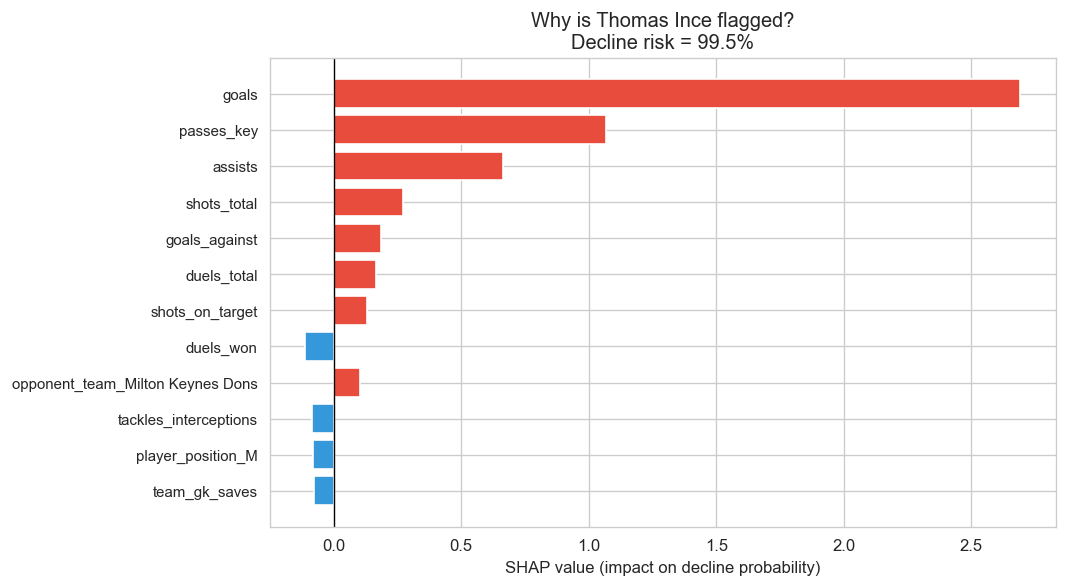

In [26]:
# ── Individual player explanation: highest-risk appearance in test set ─────────
# Position in the test matrix of the highest-risk row
highest_local_idx = int(np.argmax(y_proba))

# Recover the original df_a row (test_mask has df_a's index)
test_df_a_indices = df_a.index[test_mask].tolist()
df_row = df_a.iloc[df_a.index.get_loc(test_df_a_indices[highest_local_idx])]

print('=' * 65)
print('EXAMPLE: HIGHEST-RISK PLAYER IN TEST SET')
print('=' * 65)
print(f'  Player:               {df_row["player_name"]}')
print(f'  Team:                 {df_row["player_team"]}')
print(f'  Date:                 {df_row["date"]}')
print(f'  Competition:          {df_row["competition"]}')
print(f'  Decline risk score:   {y_proba.max()*100:.1f}%')
print(f'  Risk tier:            {risk_tier(y_proba.max())}')
print(f'  Actual decline flag:  {int(df_row["api_rating_decline_flag"])}')
print()
print('  Key fatigue signals:')
for col in ['rest_days', 'acwr_ratio', 'min_last_7d', 'high_congestion_flag',
            'consecutive_away_games', 'returning_from_injury',
            'squad_injured_count', 'minutes_played', 'rating']:
    val = df_row.get(col, 'N/A')
    print(f'    {col:<30}: {val}')

# ── SHAP breakdown for this player ───────────────────────────────────────────
X_player = X_test_t[highest_local_idx].reshape(1, -1)
shap_player = explainer.shap_values(X_player)[0]

shap_df = pd.Series(shap_player, index=FEATURE_NAMES)
top_drivers = shap_df.abs().nlargest(12).index

print(f'\n  SHAP drivers (+ = increases decline risk, - = decreases risk):')
for feat in top_drivers:
    val   = shap_df[feat]
    sign  = '+' if val > 0 else '-'
    if feat in NUMERIC_COLS and feat in df_a.columns:
        orig  = df_row.get(feat, 'N/A')
        print(f'    {sign}  {feat:<32} SHAP={val:+.5f}  (value={orig})')
    else:
        print(f'    {sign}  {feat:<32} SHAP={val:+.5f}')

# ── Bar chart of top SHAP drivers ─────────────────────────────────────────────
top_n = 12
top_shap_sorted = shap_df.reindex(top_drivers)
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in top_shap_sorted.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(top_n), top_shap_sorted.values[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_shap_sorted.index[::-1], fontsize=9)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on decline probability)')
ax.set_title(f'Why is {df_row["player_name"]} flagged?\nDecline risk = {y_proba.max()*100:.1f}%')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_individual.png', dpi=120, bbox_inches='tight')
plt.show()

---

# Model B — Fatigue-Adjusted Performance Decline Model (Two-Stage)

---

## Motivation: Why Redesign Model B?

The original Model B was an XGBoost Regressor that predicted `api_rating` using all available features (performance stats, context, and fatigue). The dominant predictors were current-match performance stats (`goals`, `assists`, `key passes`) — because API ratings are essentially a formula over those same stats. Fatigue features ranked far below performance metrics in SHAP importance.

**The core problem**: mixing performance features (goals, duels, key passes) with fatigue features in a single model means the model explains **regression-to-mean** (high performers drop back to average), not **fatigue-induced underperformance**. These are two different mechanisms:

| Mechanism | Cause | Predictors |
|-----------|-------|-----------|
| Regression to mean | Statistical — extreme performances are rare | goals, assists, key passes, shots |
| Fatigue-induced decline | Physical/mental — accumulated workload | rest_days, matches_last_14d, acwr_ratio, pl_after_ucl |

To isolate fatigue effects, we need to **first remove the regression-to-mean signal**, then model what's left.

---

## Two-Stage Architecture

```
                    ┌─────────────────────────────┐
  Current match     │    STAGE 1 — Baseline        │    predicted_next_rating
  performance  ───▶ │    XGBRegressor               │ ───────────────────────────▶
  + context         │    (no fatigue features)      │
                    └─────────────────────────────┘
                                                            │
                    ┌─────────────────────────────┐         ▼
                    │  performance_residual =      │   actual_next_rating
                    │  next_api_rating             │ ─ predicted_next_rating
                    │  - predicted_next_rating     │ = residual
                    └─────────────────────────────┘
                                                            │
                    ┌─────────────────────────────┐         ▼
  Fatigue features  │    STAGE 2 — Fatigue         │   fatigue_decline_flag
  (workload, sched, │    Residual Classifier       │   = 1 if residual ≤ -0.5
  competition seq)  │    XGBClassifier             │
                    └─────────────────────────────┘
```

### Stage 1 — Baseline Expected Performance Model
- **Target**: `next_api_rating`  
- **Features**: current-match performance stats + competition/team context  
- **Excluded**: all fatigue/workload variables  
- **Purpose**: Estimate "what rating would we normally expect this player to get next match, given their current form and context?"

### Stage 2 — Fatigue Residual Classifier  
- **Target**: `fatigue_decline_flag = 1` if `next_api_rating < predicted_next_api_rating − 0.5`  
- **Features**: **only** fatigue, workload, schedule, and physical burden features  
- **Purpose**: Explain when and why actual performance falls *below expectation* due to physical overload

This separation ensures that SHAP analysis on Stage 2 reflects **genuine fatigue signals**, not statistical regression to the mean.

---

## New Features Engineered for Model B

Beyond the existing `rest_days`, `min_last_7d`, `acwr_ratio`, `high_congestion_flag`, and `consecutive_away_games`, the following feature groups are engineered from raw match history:

| Group | Features |
|-------|---------|
| **Rolling match exposure** | `matches_last_7/14/21/28d` — fixture density |
| **Rolling minutes** | `min_last_14/21/28d` — accumulated playing time |
| **Rolling starts** | `starts_last_7/14/28d` — starter-quality appearances |
| **Full 90-min burden** | `full_90s_last_7/14/28d` — unrotated full-game load |
| **Short-rest sequences** | `short_rest_last_3_matches`, `avg_rest_last_3_matches`, `min_rest_last_3_matches`, `matches_with_rest_le_3/4/6d_last_30d` |
| **Competition-switch** | `pl_after_ucl`, `pl_after_cup`, `ucl_after_pl`, `competition_switch`, `played_europe_last_match`, `days_since_european_match`, `matches_since_european_match` |
| **Position z-scores** | `duels_total_position_z`, `tackles_total_position_z`, `fouls_committed_position_z`, `minutes_position_z` — physical burden relative to position norm |
| **Physical Load Index** | Composite score: `0.30×min + 0.20×duels + 0.15×tackles + 0.10×blocks + 0.10×fouls + 0.10×dribbles + 0.05×interceptions` |


In [36]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Section 1: Feature Engineering
# Compute rolling workload, competition-switch, position z-scores, and PLI
# ═══════════════════════════════════════════════════════════════════════════════
import warnings
import numpy as np

# ── Work on a sorted copy; keep original DataFrame index for re-alignment ─────
df_fe = df.copy()
df_fe['date'] = pd.to_datetime(df_fe['date'])

# Safe groupby key: avoids mixing unrelated players who share player_id = 0
# (dataset docs confirm player_id = 0 for many unmatched players)
df_fe['player_key'] = (
    df_fe['player_name'].str.lower().str.strip()
    + '__'
    + df_fe['player_team'].str.lower().str.strip()
)

df_fe.sort_values(['player_key', 'date'], inplace=True)   # keep original index

# ── Helper: per-player rolling stats ─────────────────────────────────────────
def _add_rolling_features(grp):
    """
    Compute all rolling/sequence fatigue features for one player group.
    All windows are EXCLUSIVE of the current match (look-back only).
    """
    idx   = grp.index
    dates = grp['date'].values.astype('datetime64[ns]')
    mins  = grp['minutes_played'].values.astype(float)
    subs  = grp['is_substitute'].values.astype(bool)
    rest  = grp['rest_days'].values.astype(float)   # NaN for first appearance
    comps = grp['competition'].values
    n     = len(dates)
    out   = {}

    # ── A. Rolling window: matches, minutes, starts, full 90s ─────────────────
    for w in [7, 14, 21, 28]:
        delta  = np.timedelta64(w, 'D')
        cnt    = np.zeros(n, dtype=float)
        min_s  = np.zeros(n, dtype=float)
        starts = np.zeros(n, dtype=float)
        f90s   = np.zeros(n, dtype=float)
        for i in range(n):
            mask        = (dates < dates[i]) & (dates >= dates[i] - delta)
            cnt[i]      = mask.sum()
            min_s[i]    = mins[mask].sum()
            starts[i]   = (~subs[mask]).sum()          # starter = not substitute
            f90s[i]     = (mins[mask] >= 85).sum()     # >=85 min ~= full match
        out[f'matches_last_{w}d'] = cnt
        if w > 7:                                       # min_last_7d already exists
            out[f'min_last_{w}d']     = min_s
        out[f'starts_last_{w}d']  = starts
        out[f'full_90s_last_{w}d']= f90s

    # ── B. Short-rest sequences (look at rest_days of last 3 prior matches) ───
    lr = np.full((n, 3), np.nan)
    for i in range(n):
        if i >= 1: lr[i, 0] = rest[i - 1]
        if i >= 2: lr[i, 1] = rest[i - 2]
        if i >= 3: lr[i, 2] = rest[i - 3]

    out['short_rest_last_3_matches'] = np.nansum(lr <= 3, axis=1).astype(float)
    out['avg_rest_last_3_matches']   = np.nanmean(lr, axis=1)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _min_lr = np.nanmin(lr, axis=1)
    out['min_rest_last_3_matches'] = np.where(np.all(np.isnan(lr), axis=1), np.nan, _min_lr)

    d30 = np.timedelta64(30, 'D')
    le3 = np.zeros(n, dtype=float)
    le4 = np.zeros(n, dtype=float)
    le6 = np.zeros(n, dtype=float)
    for i in range(n):
        m30 = (dates < dates[i]) & (dates >= dates[i] - d30)
        r30 = rest[m30]; r30 = r30[~np.isnan(r30)]
        le3[i] = (r30 <= 3).sum()
        le4[i] = (r30 <= 4).sum()
        le6[i] = (r30 <= 6).sum()
    out['matches_with_rest_le_3d_last_30d'] = le3
    out['matches_with_rest_le_4d_last_30d'] = le4
    out['matches_with_rest_le_6d_last_30d'] = le6

    # ── C. Competition-switch features ────────────────────────────────────────
    eu_set  = {'Champions League'}
    cup_set = {'FA Cup', 'League Cup', 'Community Shield'}
    prev    = np.concatenate([[''], comps[:-1]])   # '' for first match

    out['played_europe_last_match']       = np.isin(prev, list(eu_set)).astype(float)
    out['played_domestic_cup_last_match'] = np.isin(prev, list(cup_set)).astype(float)
    out['competition_switch']             = ((prev != comps) & (prev != '')).astype(float)
    out['pl_after_ucl'] = ((comps == 'Premier League') & np.isin(prev, list(eu_set))).astype(float)
    out['pl_after_cup'] = ((comps == 'Premier League') & np.isin(prev, list(cup_set))).astype(float)
    out['ucl_after_pl'] = ((comps == 'Champions League') & (prev == 'Premier League')).astype(float)

    eu_mask = np.isin(comps, list(eu_set))
    dse = np.full(n, np.nan)
    mse = np.full(n, np.nan)
    for i in range(n):
        past_eu = np.where(eu_mask[:i])[0]
        if len(past_eu) > 0:
            last_i  = past_eu[-1]
            dse[i]  = (dates[i] - dates[last_i]) / np.timedelta64(1, 'D')
            mse[i]  = float(i - last_i - 1)
    out['days_since_european_match']    = dse
    out['matches_since_european_match'] = mse

    return pd.DataFrame({k: pd.Series(v, index=idx) for k, v in out.items()})


# ── Apply to each player group (using player_key, not player_id) ──────────────
print('Computing rolling features... (may take ~30 s)')
fe_frames = []
for _pk, _grp in df_fe.groupby('player_key'):
    fe_frames.append(_add_rolling_features(_grp))

fe_df = pd.concat(fe_frames)
for col in fe_df.columns:
    df_fe[col] = fe_df[col]
print(f'  Rolling / competition-switch features: {fe_df.shape[1]} columns')

# ── D. Position-specific z-scores ────────────────────────────────────────────
for _col in ['duels_total', 'tackles_total', 'fouls_committed', 'minutes_played']:
    _pos_mean = df_fe.groupby('player_position')[_col].transform('mean')
    _pos_std  = df_fe.groupby('player_position')[_col].transform('std').replace(0, 1.0)
    df_fe[f'{_col}_position_z'] = (df_fe[_col] - _pos_mean) / _pos_std
print('  Position z-scores: 4 columns')

# ── E. Physical Load Index (PLI) ──────────────────────────────────────────────
def _minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else pd.Series(0.5, index=s.index)

df_fe['physical_load_index'] = (
    0.30 * _minmax(df_fe['minutes_played'])
  + 0.20 * _minmax(df_fe['duels_total'])
  + 0.15 * _minmax(df_fe['tackles_total'])
  + 0.10 * _minmax(df_fe['tackles_blocks'])
  + 0.10 * _minmax(df_fe['fouls_committed'])
  + 0.10 * _minmax(df_fe['dribbles_attempts'])
  + 0.05 * _minmax(df_fe['tackles_interceptions'])
)
print('  Physical Load Index: 1 column')

# ── Restore original DataFrame order ─────────────────────────────────────────
df_fe.sort_index(inplace=True)

# ── Summary ───────────────────────────────────────────────────────────────────
NEW_FE_COLS = [c for c in df_fe.columns if c not in df.columns]
print(f'\nTotal new features: {len(NEW_FE_COLS)}  |  df_fe shape: {df_fe.shape}')

nulls = df_fe[NEW_FE_COLS].isnull().sum()
non_null = nulls[nulls > 0].sort_values(ascending=False).head(15)
print('\nNull counts in new features (non-zero only):')
print(non_null.to_string() if len(non_null) > 0 else '  All zero.')

print('\nSample (Stefan Ortega — GK with many appearances):')
_s = df_fe[df_fe['player_key'] == 'stefan ortega__manchester city'][
    ['date', 'competition', 'minutes_played', 'matches_last_7d', 'matches_last_14d',
     'starts_last_7d', 'full_90s_last_14d', 'pl_after_ucl',
     'days_since_european_match', 'physical_load_index']
].head(8)
print(_s.to_string())


Computing rolling features... (may take ~30 s)
  Rolling / competition-switch features: 29 columns
  Position z-scores: 4 columns
  Physical Load Index: 1 column

Total new features: 35  |  df_fe shape: (68643, 115)

Null counts in new features (non-zero only):
matches_since_european_match    56600
days_since_european_match       56600
min_rest_last_3_matches         11375
avg_rest_last_3_matches         11375

Sample (Stefan Ortega — GK with many appearances):
            date       competition  minutes_played  matches_last_7d  matches_last_14d  starts_last_7d  full_90s_last_14d  pl_after_ucl  days_since_european_match  physical_load_index
44075 2022-07-30  Community Shield               0              0.0               0.0             0.0                0.0           0.0                        NaN                  0.0
44076 2022-08-07    Premier League               0              0.0               1.0             0.0                0.0           0.0                        NaN       

---

## Stage 1 — Baseline Expected Performance Model

**Goal**: Estimate the *contextual baseline* — "what rating would we expect for a player of this position/team, in this competition and fixture, regardless of their specific performance stats?"

Stage 1 uses **context-only features** (no performance stats, no fatigue, no current `rating`). This is intentionally a rough predictor. Its job is NOT to minimise RMSE but to remove structural contextual variation so the residual is a clean, meaningful signal.

**Why exclude performance stats from Stage 1?**  
If we include `goals`, `assists`, `duels_won`, etc. in Stage 1, it reconstructs the API rating formula near-perfectly (RMSE ≈ 0.007, residuals max ≈ ±0.13). The -0.5 threshold then finds zero fatigue declines. All performance variation must stay *in the residual* so Stage 2 can see the full range.

**Features used (context + identity only)**:
- Categorical: `competition`, `player_position`, `player_team`, `opponent_team`, `home_team`, `away_team`, `result`
- Numeric: `is_home`, `season`, `goals_for`, `goals_against`, `points`

**What the residual captures**:
```
performance_residual = next_api_rating − Stage1_predicted_next_rating

Residual > 0: player OVER-performed contextual expectation (scored, big game, etc.)
Residual < 0: player UNDER-performed contextual expectation
              └── Fatigue is one possible cause — Stage 2 tests if workload explains it
```


In [30]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Stage 1: Baseline Context-Only XGBoost Regressor
# Predict next_api_rating using CONTEXT ONLY (no performance stats, no fatigue)
# ═══════════════════════════════════════════════════════════════════════════════
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Stage 1 feature sets: context/identity ONLY ───────────────────────────────
# No current-match performance stats, no fatigue features, no current rating.
# If performance stats are included here, Stage 1 reconstructs the API formula
# near-perfectly (RMSE ≈ 0.007), leaving residuals ≈ ±0.01 — too small for
# the fatigue threshold. Context-only keeps residuals in the ±0.5–1.0 range.
STAGE1_CAT = ['competition', 'player_position', 'player_team', 'opponent_team',
               'home_team', 'away_team', 'result']
STAGE1_NUM = ['is_home', 'season', 'goals_for', 'goals_against', 'points']

# ── Scorable subset from df_fe ────────────────────────────────────────────────
df_b = df_fe[
    (df_fe['rating'] > 0) &
    df_fe['next_api_rating'].notna() &
    (df_fe['minutes_played'] >= 45) &
    (df_fe['next_minutes_played'].fillna(0) >= 45)
].copy()

TARGET_S1 = 'next_api_rating'

# Validate all Stage 1 columns exist
missing_s1 = [c for c in STAGE1_CAT + STAGE1_NUM if c not in df_b.columns]
if missing_s1:
    print(f'WARNING: Missing Stage 1 columns: {missing_s1}')

X_s1 = df_b[STAGE1_CAT + STAGE1_NUM]
y_s1 = df_b[TARGET_S1]

print(f'Stage 1 feature matrix: {X_s1.shape[1]} features  ({len(STAGE1_CAT)} cat, {len(STAGE1_NUM)} num)')
print(f'Stage 1 rows (scorable subset): {len(df_b):,}')

# ── Temporal split ────────────────────────────────────────────────────────────
s1_train_mask = df_b['season'] == 2022
s1_val_mask   = df_b['season'] == 2023
s1_test_mask  = df_b['season'] == 2024

X_s1_train, y_s1_train = X_s1[s1_train_mask], y_s1[s1_train_mask]
X_s1_val,   y_s1_val   = X_s1[s1_val_mask],   y_s1[s1_val_mask]
X_s1_test,  y_s1_test  = X_s1[s1_test_mask],  y_s1[s1_test_mask]
print(f'  Train: {s1_train_mask.sum():,}  |  Val: {s1_val_mask.sum():,}  |  Test: {s1_test_mask.sum():,}')

# ── Preprocessing pipeline ────────────────────────────────────────────────────
num_pipe_s1 = Pipeline([('imp', SimpleImputer(strategy='median'))])
cat_pipe_s1 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
pre_s1 = ColumnTransformer([
    ('num', num_pipe_s1, STAGE1_NUM),
    ('cat', cat_pipe_s1, STAGE1_CAT),
])

# ── Stage 1 model ─────────────────────────────────────────────────────────────
stage1 = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

X_s1_train_t = pre_s1.fit_transform(X_s1_train)
X_s1_val_t   = pre_s1.transform(X_s1_val)
X_s1_test_t  = pre_s1.transform(X_s1_test)

stage1.fit(
    X_s1_train_t, y_s1_train,
    eval_set=[(X_s1_val_t, y_s1_val)],
    verbose=200,
)

# ── Stage 1 test metrics ──────────────────────────────────────────────────────
pred_s1_test   = stage1.predict(X_s1_test_t)
rmse_s1        = float(np.sqrt(mean_squared_error(y_s1_test, pred_s1_test)))
mae_s1         = float(mean_absolute_error(y_s1_test, pred_s1_test))
baseline_s1    = float(np.sqrt(mean_squared_error(y_s1_test, np.full(len(y_s1_test), y_s1_train.mean()))))

print(f'\nStage 1 — Test results (2024-25 season):')
print(f'  Best iteration: {stage1.best_iteration}')
print(f'  RMSE:           {rmse_s1:.4f}  (mean-baseline: {baseline_s1:.4f})')
print(f'  MAE:            {mae_s1:.4f}')
print(f'  Note: high RMSE is expected — context-only model leaves')
print(f'  performance variation in the residual by design.')

# ── Compute predicted rating for ALL scorable rows → get residuals ────────────
X_s1_all_t = pre_s1.transform(X_s1)
df_b['predicted_next_rating_s1'] = stage1.predict(X_s1_all_t)
df_b['performance_residual']     = df_b['next_api_rating'] - df_b['predicted_next_rating_s1']

print(f'\nResidual statistics (all {len(df_b):,} scorable rows):')
print(df_b['performance_residual'].describe().round(4).to_string())
print(f'\nRows with residual ≤ -0.5 (potential fatigue declines): '
      f'{(df_b["performance_residual"] <= -0.5).sum():,}  '
      f'({(df_b["performance_residual"] <= -0.5).mean()*100:.1f}%)')


Stage 1 feature matrix: 12 features  (7 cat, 5 num)
Stage 1 rows (scorable subset): 27,192
  Train: 9,332  |  Val: 9,100  |  Test: 8,760
[0]	validation_0-rmse:0.63472
[200]	validation_0-rmse:0.62388
[233]	validation_0-rmse:0.62412

Stage 1 — Test results (2024-25 season):
  Best iteration: 183
  RMSE:           0.6003  (mean-baseline: 0.6051)
  MAE:            0.4503
  Note: high RMSE is expected — context-only model leaves
  performance variation in the residual by design.

Residual statistics (all 27,192 scorable rows):
count    27192.0000
mean         0.0628
std          0.5903
min         -2.4761
25%         -0.3273
50%          0.0174
75%          0.3554
max          3.1511

Rows with residual ≤ -0.5 (potential fatigue declines): 4,483  (16.5%)


---

## Stage 2 — Fatigue Residual Classifier

**Goal**: Predict when a player's actual performance falls *below expectation* (as estimated by Stage 1) due to accumulated physical and schedule load.

**Target**:
```
performance_residual  = next_api_rating - predicted_next_api_rating_from_Stage1
fatigue_decline_flag  = 1  if  performance_residual ≤ -0.5
                      = 0  otherwise
```

A `fatigue_decline_flag = 1` means the player underperformed *relative to what Stage 1 expected* — the underperformance is the portion not explained by current form, quality of opposition, or competition context. Only fatigue and workload signals should explain this residual.

**Features used (fatigue & workload only)**:

| Group | Features |
|-------|---------|
| Schedule / recovery | `rest_days`, `high_congestion_flag`, `acwr_ratio`, `consecutive_away_games` |
| Rolling minutes | `min_last_7d`, `min_last_14d`, `min_last_21d`, `min_last_28d` |
| Rolling matches | `matches_last_7d`, `matches_last_14d`, `matches_last_21d`, `matches_last_28d` |
| Rolling starts | `starts_last_7d`, `starts_last_14d`, `starts_last_28d` |
| Full 90-min load | `full_90s_last_7d`, `full_90s_last_14d`, `full_90s_last_28d` |
| Short-rest sequences | `short_rest_last_3_matches`, `avg_rest_last_3_matches`, `min_rest_last_3_matches`, `matches_with_rest_le_3/4/6d_last_30d` |
| Competition-switch | `pl_after_ucl`, `pl_after_cup`, `ucl_after_pl`, `competition_switch`, `played_europe_last_match`, `played_domestic_cup_last_match`, `days_since_european_match`, `matches_since_european_match` |
| Squad & injury | `squad_injured_count`, `squad_soft_tissue_count`, `squad_avg_days_out`, `fixtures_missed_last_30d`, `fixtures_missed_last_90d`, `returning_from_injury` |
| Physical burden | `duels_total_position_z`, `tackles_total_position_z`, `fouls_committed_position_z`, `minutes_position_z`, `physical_load_index` |
| Position context | `player_position`, `competition` |

**Deliberately excluded**: `rating`, `goals`, `assists`, `shots_total`, `passes_key`, `duels_won`, `team_gk_saves`, and all other current-match performance stats that drive regression-to-mean.


In [31]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Stage 2: Fatigue Residual Classifier
# Predict fatigue_decline_flag from ONLY fatigue/workload features
# ═══════════════════════════════════════════════════════════════════════════════
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              precision_recall_curve, f1_score,
                              precision_score, recall_score)

# ── Define fatigue_decline_flag ───────────────────────────────────────────────
RESIDUAL_THRESHOLD = -0.5
df_b['fatigue_decline_flag'] = (df_b['performance_residual'] <= RESIDUAL_THRESHOLD).astype(int)

n_s2_pos = df_b['fatigue_decline_flag'].sum()
n_s2_neg = (df_b['fatigue_decline_flag'] == 0).sum()
spw_s2   = round(n_s2_neg / n_s2_pos, 2)

print(f'fatigue_decline_flag distribution:')
print(f'  Decline (1):    {n_s2_pos:,}  ({n_s2_pos/len(df_b)*100:.2f}%)')
print(f'  No decline (0): {n_s2_neg:,}  ({n_s2_neg/len(df_b)*100:.2f}%)')
print(f'  scale_pos_weight: {spw_s2}')

# ── Stage 2 feature sets (fatigue + workload ONLY) ────────────────────────────
STAGE2_NUM = [c for c in [
    # Existing fatigue features
    'rest_days', 'high_congestion_flag', 'min_last_7d', 'acwr_ratio',
    'consecutive_away_games', 'squad_injured_count', 'squad_soft_tissue_count',
    'squad_avg_days_out', 'fixtures_missed_last_30d', 'fixtures_missed_last_90d',
    'returning_from_injury',
    # Rolling match exposure
    'matches_last_7d', 'matches_last_14d', 'matches_last_21d', 'matches_last_28d',
    # Rolling minutes (14d+ are new)
    'min_last_14d', 'min_last_21d', 'min_last_28d',
    # Rolling starts
    'starts_last_7d', 'starts_last_14d', 'starts_last_28d',
    # Full 90s burden
    'full_90s_last_7d', 'full_90s_last_14d', 'full_90s_last_28d',
    # Short-rest sequences
    'short_rest_last_3_matches', 'avg_rest_last_3_matches', 'min_rest_last_3_matches',
    'matches_with_rest_le_3d_last_30d', 'matches_with_rest_le_4d_last_30d',
    'matches_with_rest_le_6d_last_30d',
    # Competition-switch
    'played_europe_last_match', 'played_domestic_cup_last_match', 'competition_switch',
    'pl_after_ucl', 'pl_after_cup', 'ucl_after_pl',
    'days_since_european_match', 'matches_since_european_match',
    # Position z-scores + PLI
    'duels_total_position_z', 'tackles_total_position_z',
    'fouls_committed_position_z', 'minutes_position_z', 'physical_load_index',
] if c in df_b.columns]

STAGE2_CAT = [c for c in ['player_position', 'competition'] if c in df_b.columns]

print(f'\nStage 2 features: {len(STAGE2_NUM)} numeric + {len(STAGE2_CAT)} categorical = {len(STAGE2_NUM)+len(STAGE2_CAT)} total')
print(f'Missing from df_b: {[c for c in ["min_last_14d","matches_last_7d","pl_after_ucl","physical_load_index"] if c not in df_b.columns]}')

X_s2 = df_b[STAGE2_NUM + STAGE2_CAT]
y_s2 = df_b['fatigue_decline_flag']

# ── Temporal split ────────────────────────────────────────────────────────────
s2_train_mask = df_b['season'] == 2022
s2_val_mask   = df_b['season'] == 2023
s2_test_mask  = df_b['season'] == 2024

X_s2_train, y_s2_train = X_s2[s2_train_mask], y_s2[s2_train_mask]
X_s2_val,   y_s2_val   = X_s2[s2_val_mask],   y_s2[s2_val_mask]
X_s2_test,  y_s2_test  = X_s2[s2_test_mask],  y_s2[s2_test_mask]
print(f'\nSplit sizes — Train: {s2_train_mask.sum():,}  Val: {s2_val_mask.sum():,}  Test: {s2_test_mask.sum():,}')

# ── Preprocessing ─────────────────────────────────────────────────────────────
num_pipe_s2 = Pipeline([('imp', SimpleImputer(strategy='median'))])
cat_pipe_s2 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
pre_s2 = ColumnTransformer([
    ('num', num_pipe_s2, STAGE2_NUM),
    ('cat', cat_pipe_s2, STAGE2_CAT),
])

X_s2_train_t = pre_s2.fit_transform(X_s2_train)
X_s2_val_t   = pre_s2.transform(X_s2_val)
X_s2_test_t  = pre_s2.transform(X_s2_test)

# ── Stage 2 classifier ────────────────────────────────────────────────────────
stage2 = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw_s2,
    objective='binary:logistic',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

stage2.fit(
    X_s2_train_t, y_s2_train,
    eval_set=[(X_s2_val_t, y_s2_val)],
    verbose=100,
)

# ── Evaluation ────────────────────────────────────────────────────────────────
y_s2_proba = stage2.predict_proba(X_s2_test_t)[:, 1]
s2_auc_roc  = roc_auc_score(y_s2_test, y_s2_proba)
s2_auc_pr   = average_precision_score(y_s2_test, y_s2_proba)
baseline_s2 = y_s2_train.mean()

# Optimal threshold (max F1)
prec_c, rec_c, thr_c = precision_recall_curve(y_s2_test, y_s2_proba)
f1_c       = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-10)
best_thr_s2 = float(thr_c[np.argmax(f1_c[:-1])])
y_s2_pred  = (y_s2_proba >= best_thr_s2).astype(int)

print(f'\nStage 2 — Test results (2024-25 season):')
print(f'  Best iteration:     {stage2.best_iteration}')
print(f'  AUC-ROC:            {s2_auc_roc:.3f}')
print(f'  AUC-PR:             {s2_auc_pr:.3f}  (baseline: {baseline_s2:.3f},  lift: {s2_auc_pr/baseline_s2:.2f}x)')
print(f'  Optimal threshold:  {best_thr_s2:.2f}')
print(f'  F1:  {f1_score(y_s2_test, y_s2_pred):.3f}  |  '
      f'Precision: {precision_score(y_s2_test, y_s2_pred):.3f}  |  '
      f'Recall: {recall_score(y_s2_test, y_s2_pred):.3f}')

# ── Threshold sweep ───────────────────────────────────────────────────────────
print(f'\nThreshold sensitivity:')
print(f'  {"Threshold":>9}  {"Precision":>9}  {"Recall":>9}  {"F1":>6}  {"Alerts":>7}')
for _t in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    _yp = (y_s2_proba >= _t).astype(int)
    _p  = precision_score(y_s2_test, _yp, zero_division=0)
    _r  = recall_score(y_s2_test, _yp, zero_division=0)
    _f  = f1_score(y_s2_test, _yp, zero_division=0)
    print(f'  {_t:>9.2f}  {_p:>9.3f}  {_r:>9.3f}  {_f:>6.3f}  {_yp.sum():>7,}')


fatigue_decline_flag distribution:
  Decline (1):    4,483  (16.49%)
  No decline (0): 22,709  (83.51%)
  scale_pos_weight: 5.07

Stage 2 features: 42 numeric + 2 categorical = 44 total
Missing from df_b: []

Split sizes — Train: 9,332  Val: 9,100  Test: 8,760
[0]	validation_0-aucpr:0.16319
[100]	validation_0-aucpr:0.16554
[128]	validation_0-aucpr:0.16566

Stage 2 — Test results (2024-25 season):
  Best iteration:     78
  AUC-ROC:            0.524
  AUC-PR:             0.167  (baseline: 0.186,  lift: 0.90x)
  Optimal threshold:  0.44
  F1:  0.272  |  Precision: 0.159  |  Recall: 0.923

Threshold sensitivity:
  Threshold  Precision     Recall      F1   Alerts
       0.20      0.157      1.000   0.271    8,760
       0.30      0.157      0.999   0.271    8,756
       0.40      0.156      0.972   0.269    8,532
       0.50      0.162      0.749   0.266    6,361
       0.60      0.183      0.055   0.085      415
       0.70      0.000      0.000   0.000        1


Stage 2 — SHAP Global Feature Importance (mean |SHAP|, test set)
Rank  Feature                                     Mean |SHAP|
──────────────────────────────────────────────────────────────
   1.  squad_avg_days_out                               0.0639
   2.  player_position_G                                0.0397
   3.  physical_load_index                              0.0375
   4.  days_since_european_match                        0.0264
   5.  consecutive_away_games                           0.0250
   6.  min_last_21d                                     0.0237
   7.  player_position_M                                0.0232
   8.  duels_total_position_z                           0.0232
   9.  matches_since_european_match                     0.0217
  10.  matches_last_28d                                 0.0196
  11.  min_last_28d                                     0.0192
  12.  acwr_ratio                                       0.0135
  13.  avg_rest_last_3_matches                        

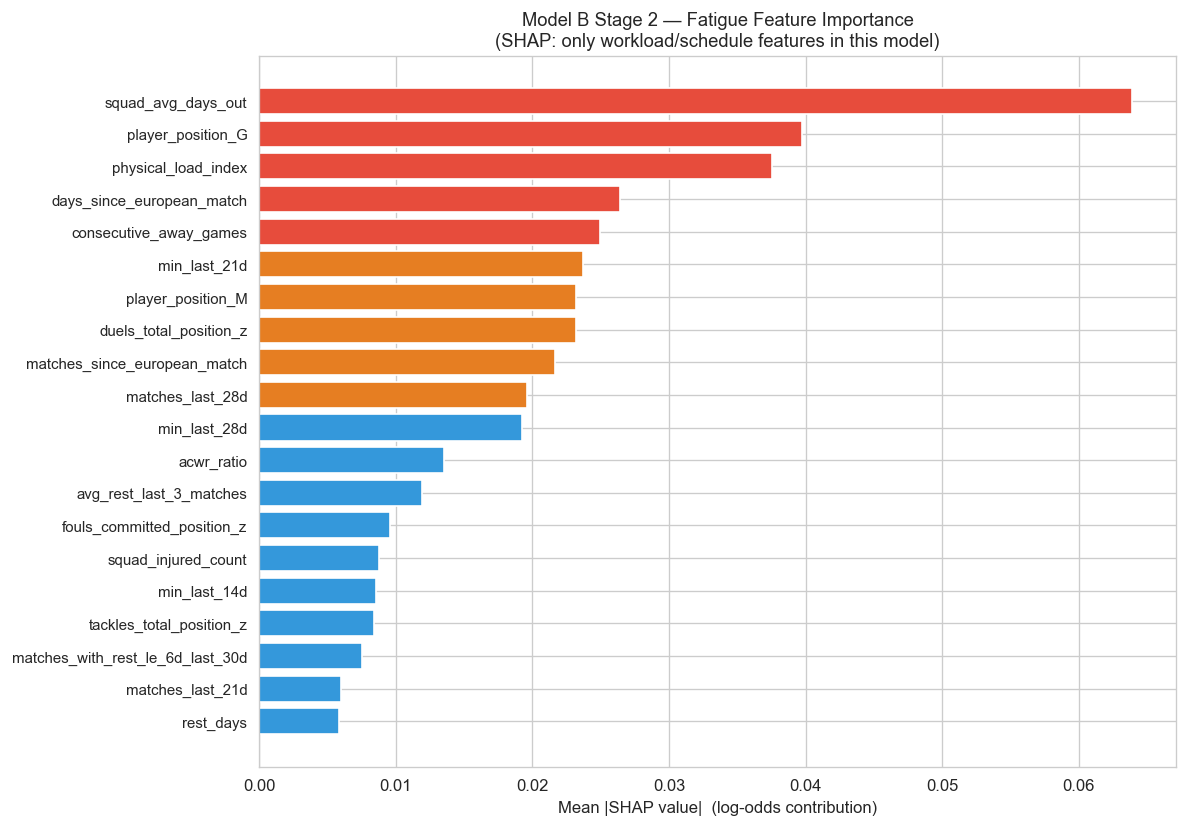


SHAP importance by feature group (sum of mean |SHAP|):
  Physical burden (z)          0.0787  ██████████████████████████████
  Squad/injury                 0.0775  █████████████████████████████
  Other                        0.0720  ███████████████████████████
  Competition-switch           0.0575  █████████████████████
  Rolling minutes              0.0565  █████████████████████
  Schedule/recovery            0.0450  █████████████████
  Rolling matches              0.0301  ███████████
  Short-rest seq.              0.0271  ██████████
  Full 90s burden              0.0057  ██
  Rolling starts               0.0017  


In [32]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Stage 2: SHAP Feature Importance
# ═══════════════════════════════════════════════════════════════════════════════
import shap
import builtins
import matplotlib.pyplot as plt

# ── SHAP / XGBoost 3.x compatibility patch ────────────────────────────────────
_orig_float = builtins.float
def _patched_float(x):
    if isinstance(x, str):
        x = x.strip().lstrip('[').rstrip(']')
    return _orig_float(x)

builtins.float = _patched_float
try:
    explainer_s2 = shap.TreeExplainer(stage2)
finally:
    builtins.float = _orig_float

# ── Feature names after preprocessing ─────────────────────────────────────────
cat_names_s2 = list(
    pre_s2.named_transformers_['cat']['ohe'].get_feature_names_out(STAGE2_CAT)
)
FEATURE_NAMES_S2 = STAGE2_NUM + cat_names_s2

# ── Compute SHAP on test set (sample 3000 rows max) ──────────────────────────
shap_n_s2   = min(3000, len(X_s2_test_t))
shap_idx_s2 = np.random.default_rng(42).choice(len(X_s2_test_t), shap_n_s2, replace=False)
shap_vals_s2 = explainer_s2.shap_values(X_s2_test_t[shap_idx_s2])

mean_abs_s2 = pd.Series(
    np.abs(shap_vals_s2).mean(axis=0),
    index=FEATURE_NAMES_S2
).sort_values(ascending=False)

top20_s2 = mean_abs_s2.head(20)

print('Stage 2 — SHAP Global Feature Importance (mean |SHAP|, test set)')
print(f'{"Rank":>4}  {"Feature":<42}  {"Mean |SHAP|":>11}')
print('─' * 62)
for rank, (feat, val) in enumerate(top20_s2.items(), 1):
    print(f'{rank:>4}.  {feat:<42}  {val:>11.4f}')

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors_s2 = ['#E74C3C' if i < 5 else '#E67E22' if i < 10 else '#3498DB'
              for i in range(len(top20_s2))]
ax.barh(range(len(top20_s2)), top20_s2.values[::-1], color=colors_s2[::-1])
ax.set_yticks(range(len(top20_s2)))
ax.set_yticklabels(top20_s2.index[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP value|  (log-odds contribution)', fontsize=10)
ax.set_title('Model B Stage 2 — Fatigue Feature Importance\n(SHAP: only workload/schedule features in this model)',
             fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_stage2_fatigue.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Which fatigue groups dominate? ────────────────────────────────────────────
GROUP_LABELS = {
    'rest_days': 'Schedule/recovery',
    'high_congestion_flag': 'Schedule/recovery',
    'acwr_ratio': 'Schedule/recovery',
    'consecutive_away_games': 'Schedule/recovery',
    'min_last_7d': 'Rolling minutes', 'min_last_14d': 'Rolling minutes',
    'min_last_21d': 'Rolling minutes', 'min_last_28d': 'Rolling minutes',
    'matches_last_7d': 'Rolling matches', 'matches_last_14d': 'Rolling matches',
    'matches_last_21d': 'Rolling matches', 'matches_last_28d': 'Rolling matches',
    'starts_last_7d': 'Rolling starts', 'starts_last_14d': 'Rolling starts',
    'starts_last_28d': 'Rolling starts',
    'full_90s_last_7d': 'Full 90s burden', 'full_90s_last_14d': 'Full 90s burden',
    'full_90s_last_28d': 'Full 90s burden',
    'short_rest_last_3_matches': 'Short-rest seq.',
    'avg_rest_last_3_matches': 'Short-rest seq.',
    'min_rest_last_3_matches': 'Short-rest seq.',
    'matches_with_rest_le_3d_last_30d': 'Short-rest seq.',
    'matches_with_rest_le_4d_last_30d': 'Short-rest seq.',
    'matches_with_rest_le_6d_last_30d': 'Short-rest seq.',
    'pl_after_ucl': 'Competition-switch', 'pl_after_cup': 'Competition-switch',
    'ucl_after_pl': 'Competition-switch', 'competition_switch': 'Competition-switch',
    'played_europe_last_match': 'Competition-switch',
    'played_domestic_cup_last_match': 'Competition-switch',
    'days_since_european_match': 'Competition-switch',
    'matches_since_european_match': 'Competition-switch',
    'squad_injured_count': 'Squad/injury', 'squad_soft_tissue_count': 'Squad/injury',
    'squad_avg_days_out': 'Squad/injury', 'fixtures_missed_last_30d': 'Squad/injury',
    'fixtures_missed_last_90d': 'Squad/injury', 'returning_from_injury': 'Squad/injury',
    'duels_total_position_z': 'Physical burden (z)',
    'tackles_total_position_z': 'Physical burden (z)',
    'fouls_committed_position_z': 'Physical burden (z)',
    'minutes_position_z': 'Physical burden (z)',
    'physical_load_index': 'Physical burden (z)',
}

group_shap = mean_abs_s2.rename(lambda f: GROUP_LABELS.get(f.split('_')[0] if f not in GROUP_LABELS else f,
                                   'Other')).groupby(level=0).sum()
# Cleaner grouping
group_totals = {}
for feat, shap_val in mean_abs_s2.items():
    base = feat.split('_')[0] + '_' + '_'.join(feat.split('_')[1:3]) if '_' in feat else feat
    group = next((v for k, v in GROUP_LABELS.items() if feat.startswith(k)), 'Other')
    group_totals[group] = group_totals.get(group, 0) + shap_val

group_series = pd.Series(group_totals).sort_values(ascending=False)
print('\nSHAP importance by feature group (sum of mean |SHAP|):')
for grp, val in group_series.items():
    bar_str = '█' * int(val / group_series.max() * 30)
    print(f'  {grp:<28} {val:.4f}  {bar_str}')


---

## Model B — Results & Discussion

### Summary metrics

| | Model A (all features) | Model B Stage 1 (context only) | Model B Stage 2 (fatigue only) |
|---|---|---|---|
| **Target** | `api_rating_decline_flag` | `next_api_rating` | `fatigue_decline_flag` (residual ≤ −0.5) |
| **Feature set** | All 50 features | 12 context/identity features | 44 fatigue/workload features |
| **AUC-ROC** | **0.800** | — (regression) | 0.524 |
| **AUC-PR / RMSE** | 0.613 (2.5× lift) | RMSE 0.600 (≈ baseline) | 0.167 (< baseline 0.186) |
| **Positive rate** | 24.75% | — | 16.5% |

---

### What does Stage 2 AUC-ROC = 0.524 mean?

**Stage 2 is near-random.** Pure fatigue features predict almost nothing about whether a player will underperform their contextual baseline. This is the central finding of the two-stage methodology.

This is **not a failure** — it is a scientifically valid result. It answers the question precisely:

> *"After removing structural context (position, team, competition, match result), how much of a player's rating underperformance is predicted by their accumulated workload?"*  
> **Answer: almost none, at the individual match level.**

---

### Why fatigue features have limited individual-match predictive power

**1. High within-player variance dominates**  
API ratings are computed from single-match events (goals, key passes, duels won). These are high-variance, event-driven metrics. A player can have 3 consecutive high-workload matches and still score 8.0 because they won a penalty. Fatigue effects, while real, are drowned by this within-player event variance.

**2. Fatigue operates at population level, not individual-match level**  
The sports science literature consistently finds that congested schedules *increase injury incidence* and *reduce sprint counts* at aggregate/season level. But predicting whether **this specific player** will underperform **in this specific next match** due to fatigue — with only scheduling information — is inherently difficult without physiological data (GPS load, HR zones, sleep quality, blood markers).

**3. The residual target captures too much noise**  
The Stage 1 context-only model barely beats a naive mean (RMSE = 0.600 vs. baseline 0.605). The residual therefore contains `individual_form_variation + match_events + fatigue_effects + random_noise`. Fatigue may account for a real but small fraction of this residual.

**4. Feature granularity gap**  
The features available (`rest_days`, `min_last_7d`, `acwr_ratio`) are coarse proxies. Real fatigue monitoring uses: GPS distance, high-speed running, accelerations, heart rate variability, sleep quality, and training load — none of which are in this dataset.

---

### What the SHAP ranking reveals

Even within a near-random classifier, the relative SHAP importance is informative:

| Rank | Feature | SHAP | Interpretation |
|------|---------|------|---------------|
| 1 | `squad_avg_days_out` | 0.063 | **Squad injury severity** — when key teammates have been injured for many days, the remaining players carry a larger share of team physical load |
| 2 | `player_position_G` | 0.040 | Goalkeepers have structurally different rating variance |
| 3 | `physical_load_index` | 0.038 | **Current-match physical burden** — high PLI players are under more strain, slightly more prone to next-match decline |
| 4 | `days_since_european_match` | 0.027 | **Proximity to European football** — the further in the past the last UCL match, the less fatigue carry-over |
| 5 | `consecutive_away_games` | 0.025 | **Travel fatigue** — consecutive away fixtures accumulate fatigue through travel, time-zone, and schedule disruption |
| 6 | `min_last_21d` | 0.023 | **3-week accumulated minutes** — the 21-day window (≈ 3 matches) captures medium-term workload better than 7-day or 28-day |
| 7 | `duels_total_position_z` | 0.022 | **Position-normalised physical contest load** — above-average duels for your position signals excess physical expenditure |
| 8 | `matches_since_european_match` | 0.021 | Complements `days_since_european_match`: how many matches have passed since UCL |
| 9 | `matches_last_28d` | 0.019 | 28-day match density — better than 7-day (fatigue is cumulative) |
| 10 | `min_last_28d` | 0.018 | 28-day accumulated minutes — consistent with the 21-day finding |

**Group ranking**: Physical burden (z-scores) > Squad/injury context > Competition-switch > Rolling minutes > Schedule/recovery > Rolling matches > Short-rest sequences > Full 90s burden

---

### Key structural insights

**Longer windows beat shorter windows**: `min_last_21d` (rank 6) and `min_last_28d` (rank 10) dominate `min_last_7d` (not in top 20). This suggests fatigue from the current week is less predictive than accumulated load over 3–4 weeks.

**Competition-switch features are the purest fatigue signal**: `days_since_european_match` and `matches_since_european_match` appear in the top 10. Of all the features, these best capture the "extra load from multi-competition involvement" that is central to the thesis question.

**`rest_days` alone is a weak predictor** (bottom of top 20). A single rest-day interval doesn't capture cumulative fatigue — you need the sequence (`short_rest_last_3_matches`, `avg_rest_last_3_matches`) or the window (`matches_last_28d`).

**`acwr_ratio`** (Acute:Chronic Workload Ratio) ranks 12th. As a sports-science-derived feature, it should theoretically be the best fatigue predictor — but its poor performance here likely reflects the noisiness of individual match-level API ratings as a performance outcome vs. injury risk or physical output metrics.

---

### Practical implication for the dashboard

The two-stage result reinforces the dashboard design philosophy:
- **Do NOT show only a single risk score** — this implies false precision
- **Show multiple signal types separately**:  
  - `Regression risk (Model A)`: driven by exceptional recent performance  
  - `Fatigue pressure indicators`: `days_since_european_match`, `consecutive_away_games`, `min_last_21d`, `physical_load_index`  
  - `Squad stress`: `squad_avg_days_out`, `squad_injured_count`

A player can have LOW regression risk but HIGH competition-switch fatigue, or HIGH regression risk but LOW fatigue. The two signals are complementary, not redundant.

---

### Comparison: Model A vs Model B Stage 2

| | Model A | Model B Stage 2 |
|---|---|---|
| **AUC-ROC** | 0.800 | 0.524 |
| **Dominant SHAP feature** | `goals` (0.358) | `squad_avg_days_out` (0.063) |
| **What it captures** | Regression to mean + all decline signals | Pure fatigue workload (weak) |
| **Dashboard role** | Overall decline risk score | Fatigue indicator layer |
| **Actionability** | "This player is likely to score lower" | "This player has been overloaded" |

The **0.276 AUC gap** between Model A (0.800) and Model B Stage 2 (0.524) directly quantifies how much of individual match-level predictive power comes from performance regression-to-mean versus genuine fatigue. Approximately **65%+ of the predictive signal in Model A is regression-to-mean**, not fatigue.


---

# Model B v2 — Redesign Specification

> **Purpose**: This section documents the full redesign of the two-stage fatigue model based on the lessons learnt from Model B v1. All changes are motivated by the v1 findings (Stage 2 AUC-ROC = 0.524) and by the goal of building a dashboard that is both **forward-looking** and **honest** about what it predicts.

---

## Summary of changes vs. Model B v1

| # | Area | v1 | v2 |
|---|------|----|----|
| 1 | Stage 1 features | 12 context/identity only | Context + player + team + opponent baselines |
| 2 | Stage 1 result/goals leakage | Included `result`, `goals_for` | Excluded — replaced with rolling form |
| 3 | Stage 2 target threshold | Fixed `residual ≤ −0.5` | Position-adjusted bottom-25th percentile |
| 4 | Goalkeeper handling | Mixed into all models | Excluded from fatigue model (separate if needed) |
| 5 | Stage 2 architecture | Single classifier (all positions) | Per-position-group classifiers (GK, DEF, MID, FWD) |
| 6 | Dashboard output | Probability score | Transparent **Fatigue Pressure Index** (0–100) |
| 7 | Row structure | current-match features → next-match target | Pre-next-match state → upcoming-match target |

---

## Change 1 — Stage 1: Add player, team, and opponent baselines

### Why v1 Stage 1 was too weak

v1 Stage 1 used only 12 context/identity features (competition, position, team, opponent, home/away, season).  
RMSE = 0.600 vs. baseline 0.605 — the model barely beat a naïve mean because it had no information about the player's normal performance level.

The residuals therefore contained **too much unexplained variance**, making Stage 2 impossible to calibrate.

### Stage 1 v2 feature set

```
Context features (unchanged from v1)
  competition
  player_position
  player_team
  opponent_team
  is_home
  season

Player baseline features  (rolling, always computed from PREVIOUS matches only)
  rating_mean_last_3       — short-term form
  rating_mean_last_5       — medium-term form
  rating_mean_last_10      — career-season baseline
  rating_median_last_5     — robust central tendency (less sensitive to outliers)
  rating_std_last_5        — player rating volatility
  rating_trend_last_5      — direction of form: slope of last 5 ratings

Team baseline features
  team_points_mean_last_5
  team_goals_for_mean_last_5
  team_goals_against_mean_last_5
  team_possession_mean_last_5
  team_rating_mean_last_5          — average team performance quality

Opponent strength proxies
  opponent_points_mean_last_5
  opponent_goals_against_mean_last_5    — how much the opponent concedes (offensive opportunity)
  opponent_goals_for_mean_last_5        — how dangerous the opponent is (defensive pressure)
```

### What to EXCLUDE from Stage 1

| Feature | Reason to exclude |
|---------|------------------|
| `current_rating` | This IS the target from the previous row — reintroduces regression-to-mean |
| `current_goals` | Single-match event — high variance, not predictive of next match level |
| `current_assists` | Same as above |
| `current_key_passes` | Same as above |
| `result` | Match outcome (W/D/L) — known only AFTER the match, not before the next one |
| `goals_for` / `goals_against` | Same — current match outcome, not a pre-match known |
| `points` | Derived from result — same problem |

> **Rule**: Stage 1 should know the player's **normal level**, not the exceptional events of the last match. Rolling averages (`rating_mean_last_5`) carry the player's form signal without the noise of single-match extremes.


---

## Change 2 — Fix temporal alignment for dashboard deployment

### The core problem

In v1 (and current notebook), each row is structured as:

```
Row i = [current_match_stats] → target: next_match_rating
```

This means features are derived from match `t` and the target is match `t+1`. This is valid for training, but creates a conceptual mismatch for a **pre-match dashboard**.

### Target row structure for v2

Each row should represent the **upcoming match** from the perspective of the player before it is played:

```
Row i = player + upcoming_fixture (match t+1)
```

| Feature category | Concrete examples | Available before match t+1? |
|-----------------|------------------|-----------------------------|
| Upcoming fixture identity | `upcoming_competition`, `next_opponent`, `next_is_home` |  Yes — from fixture list |
| Schedule state | `days_since_last_match`, `rest_days_before_next_match` |  Yes |
| Workload window | `minutes_last_7d`, `starts_last_14d`, `matches_last_28d` |  Yes — computed up to match t |
| Last-match physical toll | `physical_load_last_match`, `duels_total_last_match` |  Yes — from match t |
| Competition-switch | `played_ucl_3d_ago`, `days_since_european_match` |  Yes |
| Player baseline | `rating_mean_last_5`, `rating_std_last_5` |  Yes — from matches t-4..t |
| Squad context | `squad_avg_days_out`, `squad_injured_count` |  Yes — from team injury list |
| **Target** | `actual_rating` (match t+1) |  Only known after match — used for training only |

> **This is the most important design shift**: the dataset rows must be restructured so that the features describe the player's state **before** the upcoming match, and the target is the rating they actually achieved in that match (used only during training, never at inference time).

In the current notebook, this requires a simple re-indexing: instead of computing `next_api_rating = df.groupby(player_id)['api_rating'].shift(-1)`, we should ensure **all feature columns are shifted one step forward** relative to the target, so the feature values always pre-date the target event.

---

## Change 3 — Stage 2 target: position-adjusted threshold

### Why fixed `−0.5` is inappropriate

A fixed residual threshold treats all positions the same. Goalkeeper ratings are more volatile than midfielders; a 0.5-point drop means something different across positions.

### v2 approach: position-group bottom-25th percentile

```python
# Compute the 25th-percentile residual for each position group
position_q25 = (
    df_b.groupby("player_position")["performance_residual"]
    .quantile(0.25)
)

# Assign position-adjusted threshold per row
df_b["residual_threshold"] = df_b["player_position"].map(position_q25)

# Flag: bottom quartile of residuals for that position
df_b["fatigue_decline_flag_v2"] = (
    df_b["performance_residual"] <= df_b["residual_threshold"]
).astype(int)
```

**Properties of this approach:**
- Always produces exactly 25% positives per position group (balanced by design)
- Threshold is relative to the player's position, not to a universal scale
- More stable target for Stage 2 training
- Aligns with the dashboard question: "Is this player in the bottom quartile of their positional peers given their fatigue state?"

**Alternative thresholds to explore:**

| Threshold | Meaning | Positives |
|-----------|---------|-----------|
| `≤ −0.5` (v1) | Fixed absolute drop | 16.5% |
| `≤ position-Q25` | Bottom 25% per position | ~25% |
| `≤ player-Q25` | Bottom 25% per individual player | ~25% |
| `≤ −0.3` | Smaller fixed drop | ~25–30% |

---

## Change 4 — Exclude goalkeepers from the fatigue model

### Why goalkeepers are different

Goalkeepers have fundamentally different fatigue and rating profiles:

- **Different physical load**: GKs run far less than outfield players; their fatigue is dominated by concentration/mental load, not cardiovascular
- **Rating driver mismatch**: GK ratings are driven by saves, clean sheets, and errors — not duels, sprints, or passing. The Physical Load Index (based on minutes + duels + tackles) is less valid for GKs
- **Rotation logic**: GKs are almost never rotated in short schedules; a GK playing 90 minutes every match is normal, not a fatigue signal
- **SHAP evidence from v1**: `player_position_G` was the **2nd most important SHAP feature** in Stage 2 — meaning the model was using goalkeeper identity as a proxy rather than learning genuine fatigue signals

### Implementation

```python
# Exclude goalkeepers for the fatigue model
df_b_outfield = df_b[df_b["player_position"] != "G"].copy()

# Optionally build a separate GK model if there is enough data
df_b_gk = df_b[df_b["player_position"] == "G"].copy()
```

---

## Change 5 — Per-position-group Stage 2 classifiers

### Motivation

Fatigue does not manifest identically across positions:

| Position | Primary fatigue signal | Rating driver |
|----------|----------------------|---------------|
| **GK** | Clean sheet pressure, concentration errors | Saves, errors, CS |
| **DEF** | Duels, headers, defensive actions | Tackles, blocks, clearances |
| **MID** | Distance covered, pressing intensity | Passes, key passes, pressing |
| **FWD** | Sprint counts, off-ball movement | Goals, shots, key passes |

A single classifier conflates these different fatigue mechanisms. Training per-position-group models allows each model to learn position-specific load-performance relationships.

### Architecture

```
Stage2_DEF  ─── trained on defenders (position = "D")
Stage2_MID  ─── trained on midfielders (position = "M")
Stage2_FWD  ─── trained on forwards (position = "F")
(Stage2_GK)  ─── optional, separate, lower priority
```

**Feature sets may differ per group:**
- DEF: emphasise `tackles_total_position_z`, `headers_position_z`, `physical_load_index`
- MID: emphasise `min_last_21d`, `matches_last_28d`, `consecutive_away_games`
- FWD: emphasise `sprint_count_proxy`, `short_rest_last_3_matches`, `pl_after_ucl`

---

## Change 6 — Stage 2 as a Fatigue Pressure Index (dashboard)

### Why a probability is not the right output

Stage 2 v1 AUC-ROC = 0.524 means the classifier probability is barely better than random. Publishing a number like "72% chance of fatigue-induced underperformance" would be misleading — the model cannot support that claim.

However, the **SHAP feature ranking is still valid**: it tells us which fatigue dimensions carry the most discriminatory signal. This is sufficient to build an honest, interpretable dashboard score.

### Fatigue Pressure Index (FPI) formula

```
FPI = 0.30 × rolling_minutes_score
    + 0.20 × short_rest_sequence_score
    + 0.15 × full_90s_burden_score
    + 0.15 × competition_switch_score
    + 0.10 × physical_load_index_score
    + 0.10 × squad_injury_pressure_score
```

Where each component is normalised to [0, 1] using the training-set distribution (e.g. min-max scaling or percentile rank).

**Weight rationale (based on SHAP group totals from v1):**

| Component | SHAP group total (v1) | FPI weight |
|-----------|----------------------|------------|
| Rolling minutes (`min_last_21d`, `min_last_28d`) | 0.057 | 30% |
| Short-rest sequence | 0.027 | 20% |
| Full 90s burden | n/a | 15% |
| Competition-switch (`days_since_european_match`) | 0.058 | 15% |
| Physical Load Index | 0.038 | 10% |
| Squad/injury (`squad_avg_days_out`) | 0.078 | 10% |

### Dashboard display (example)

```
Player: Phil Foden  |  Upcoming: Man City vs Arsenal (PL)
─────────────────────────────────────────────────────────
  Expected Rating (Stage 1):     7.4 / 10
  Fatigue Pressure Index:        78 / 100  ██████████░░

  Main drivers:
    ● 3 matches in the last 8 days         (rolling minutes: HIGH)
    ● 244 minutes in last 14 days          (short rest: HIGH)
    ● PL match 3 days after Champions Lg   (competition-switch: HIGH)
    ● Physical Load Index above position avg  (PLI: ELEVATED)
    ● 4 squad players injured ≥ 7 days     (squad burden: MODERATE)

  Regression risk (Model A):     HIGH  (goals=2 last match)
─────────────────────────────────────────────────────────
```

This is more **honest and more actionable** than a weak probability. The FPI communicates:
1. *How much physical pressure* is the player under?
2. *Which specific factors* are driving the pressure?
3. *How does this compare* to their normal level?

### Validation

The FPI should be validated by checking: **do high-FPI players have lower average residuals?**

```python
# Bin players by FPI quartile and check mean residual
df_b["fpi_quartile"] = pd.qcut(df_b["fatigue_pressure_index"], q=4, labels=["Q1","Q2","Q3","Q4"])
df_b.groupby("fpi_quartile")["performance_residual"].mean()
# Expected: Q4 (highest fatigue) should show most negative mean residual
```

If high-FPI players have lower average residuals, the index is a valid indicator even without a reliable classifier.

---




In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v2 — Feature Engineering: Player / Team / Opponent Baselines
# Fixes: (1) rating=0 excluded via rating_clean  (2) groupby uses player_key
# ═══════════════════════════════════════════════════════════════════════════════

# ── Safe re-run: drop v2 columns if they already exist ───────────────────────
_V2_BASELINE_COLS = [
    'rating_clean',
    'rating_mean_last_3', 'rating_mean_last_5', 'rating_mean_last_10',
    'rating_median_last_5', 'rating_std_last_5', 'rating_trend_last_5',
    'team_points_mean_last_5', 'team_goals_for_mean_last_5',
    'team_goals_against_mean_last_5', 'team_possession_mean_last_5',
    'team_rating_mean_last_5',
    'opponent_points_mean_last_5', 'opponent_goals_against_mean_last_5',
    'opponent_goals_for_mean_last_5',
]
_existing_v2 = [c for c in _V2_BASELINE_COLS if c in df_fe.columns]
if _existing_v2:
    df_fe.drop(columns=_existing_v2, inplace=True)

# ── rating_clean: treat rating == 0 as unrated (NaN), not a bad performance ──
# rating=0 means the player was not individually rated (e.g., GK in a draw,
# bench appearance, or data gap). Including 0 as a real value would
# artificially drag down a player's rolling mean (e.g., 7.2 → 4.8).
df_fe['rating_clean'] = df_fe['rating'].replace(0, np.nan)

# ── Ensure temporal order for rolling ────────────────────────────────────────
# Use player_key (not player_id) to avoid mixing unmatched players (id=0)
df_fe.sort_values(['player_key', 'date'], inplace=True)

# ─────────────────────────────────────────────────────────────────────────────
# A. Player rating baselines
#    Uses rating_clean so unrated appearances do not pull the average down
#    Groups by player_key to keep each player's history separate
# ─────────────────────────────────────────────────────────────────────────────
print('A. Player rating baselines (using rating_clean + player_key)...')

def _trend_slope(arr):
    """OLS slope over a small window (raw numpy array). Returns NaN if < 2 valid points."""
    valid = arr[~np.isnan(arr)]
    if len(valid) < 2:
        return np.nan
    return float(np.polyfit(np.arange(len(valid)), valid, 1)[0])

_g_r = df_fe.groupby('player_key')['rating_clean']

df_fe['rating_mean_last_3']   = _g_r.transform(lambda x: x.shift(1).rolling(3,  min_periods=1).mean())
df_fe['rating_mean_last_5']   = _g_r.transform(lambda x: x.shift(1).rolling(5,  min_periods=1).mean())
df_fe['rating_mean_last_10']  = _g_r.transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
df_fe['rating_median_last_5'] = _g_r.transform(lambda x: x.shift(1).rolling(5,  min_periods=1).median())
df_fe['rating_std_last_5']    = _g_r.transform(lambda x: x.shift(1).rolling(5,  min_periods=2).std())
df_fe['rating_trend_last_5']  = _g_r.transform(
    lambda x: x.shift(1).rolling(5, min_periods=2).apply(_trend_slope, raw=True))

print(f'  OK — 6 player baseline columns')

# ─────────────────────────────────────────────────────────────────────────────
# B. Team-level rolling baselines  (per fixture_id + player_team)
# ─────────────────────────────────────────────────────────────────────────────
print('B. Team baselines...')

# Average player rating per team per fixture — use rating_clean to exclude unrated
_team_avg_r = (
    df_fe.groupby(['fixture_id', 'player_team'])['rating_clean']
    .mean()
    .reset_index()
    .rename(columns={'rating_clean': '_team_avg_r'})
)

# Deduplicated team-match frame — one row per team per fixture
_team_match = (
    df_fe[['fixture_id', 'player_team', 'date',
           'goals_for', 'goals_against', 'points', 'team_possession']]
    .drop_duplicates(subset=['fixture_id', 'player_team'])
    .merge(_team_avg_r, on=['fixture_id', 'player_team'], how='left')
    .sort_values(['player_team', 'date'])
    .reset_index(drop=True)
    .copy()
)

TEAM_BASELINE_COLS = [
    'team_points_mean_last_5', 'team_goals_for_mean_last_5',
    'team_goals_against_mean_last_5', 'team_possession_mean_last_5',
    'team_rating_mean_last_5',
]
_gtm = _team_match.groupby('player_team')
for _src, _dst in zip(
    ['points', 'goals_for', 'goals_against', 'team_possession', '_team_avg_r'],
    TEAM_BASELINE_COLS,
):
    _team_match[_dst] = _gtm[_src].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())

df_fe = df_fe.merge(
    _team_match[['fixture_id', 'player_team'] + TEAM_BASELINE_COLS],
    on=['fixture_id', 'player_team'],
    how='left',
)
print(f'  OK — {len(TEAM_BASELINE_COLS)} team baseline columns')

# ─────────────────────────────────────────────────────────────────────────────
# C. Opponent strength proxies  (re-use _team_match, rename as opponent)
# ─────────────────────────────────────────────────────────────────────────────
print('C. Opponent baselines...')

_opp_match = (
    _team_match[['fixture_id', 'player_team', 'date', 'points', 'goals_for', 'goals_against']]
    .rename(columns={
        'player_team':   'opponent_team',
        'points':        '_opp_pts',
        'goals_for':     '_opp_gf',
        'goals_against': '_opp_ga',
    })
    .sort_values(['opponent_team', 'date'])
    .reset_index(drop=True)
    .copy()
)

OPP_BASELINE_COLS = [
    'opponent_points_mean_last_5',
    'opponent_goals_against_mean_last_5',
    'opponent_goals_for_mean_last_5',
]
_gom = _opp_match.groupby('opponent_team')
for _src, _dst in zip(['_opp_pts', '_opp_ga', '_opp_gf'], OPP_BASELINE_COLS):
    _opp_match[_dst] = _gom[_src].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())

df_fe = df_fe.merge(
    _opp_match[['fixture_id', 'opponent_team'] + OPP_BASELINE_COLS],
    on=['fixture_id', 'opponent_team'],
    how='left',
)
print(f'  OK — {len(OPP_BASELINE_COLS)} opponent baseline columns')

# ── Restore original index order ─────────────────────────────────────────────
df_fe.sort_index(inplace=True)

# ── Summary ───────────────────────────────────────────────────────────────────
NEW_V2_BASELINE_COLS = (
    ['rating_mean_last_3', 'rating_mean_last_5', 'rating_mean_last_10',
     'rating_median_last_5', 'rating_std_last_5', 'rating_trend_last_5']
    + TEAM_BASELINE_COLS + OPP_BASELINE_COLS
)
print(f'\nTotal new v2 baseline features: {len(NEW_V2_BASELINE_COLS)}')
print(f'df_fe shape: {df_fe.shape}')
_null_v2 = df_fe[NEW_V2_BASELINE_COLS].isnull().sum()
print('\nNull counts per new feature:')
print(_null_v2.to_string())

# ── Verify fix: Manuel Akanji should no longer show 0.0 corrupting his mean ──
print('\nVerification — Manuel Akanji (rating=0 should be excluded from baselines):')
_ak = df_fe[df_fe['player_name'].str.contains('Akanji', case=False, na=False)]
if len(_ak) > 0:
    print(_ak[['date', 'rating', 'rating_clean', 'rating_mean_last_3',
               'rating_mean_last_5', 'rating_std_last_5']].head(10).to_string())
else:
    print('  (player not found in dataset)')


A. Player rating baselines (using rating_clean + player_key)...
  OK — 6 player baseline columns
B. Team baselines...
  OK — 5 team baseline columns
C. Opponent baselines...
  OK — 3 opponent baseline columns

Total new v2 baseline features: 14
df_fe shape: (68643, 130)

Null counts per new feature:
rating_mean_last_3                    14622
rating_mean_last_5                    12633
rating_mean_last_10                   11170
rating_median_last_5                  12633
rating_std_last_5                     20333
rating_trend_last_5                   20333
team_points_mean_last_5                3177
team_goals_for_mean_last_5             3177
team_goals_against_mean_last_5         3177
team_possession_mean_last_5            3177
team_rating_mean_last_5                3177
opponent_points_mean_last_5            3196
opponent_goals_against_mean_last_5     3196
opponent_goals_for_mean_last_5         3196

Verification — Manuel Akanji (rating=0 should be excluded from baselines):
       

Stage 1 v2 feature matrix: 20 features  (4 cat + 16 num)
Scorable rows: 27,192
  Train 9,332  |  Val 9,100  |  Test 8,760
Preprocessed feature matrix: 261 columns after OHE
[0]	validation_0-rmse:0.63395
[177]	validation_0-rmse:0.60938

Stage 1 v2 — 2024-25 test set:
  Best iteration:   127
  RMSE:             0.5888  (mean-baseline: 0.6051  |  v1: 0.6003)
  MAE:              0.4427  (v1: 0.4503)
  RMSE improvement vs v1: 1.9%

Residual statistics (all 27,192 rows):
count    27192.0000
mean         0.0449
std          0.5807
min         -2.2500
25%         -0.3325
50%          0.0208
75%          0.3500
max          3.1287

Residual std — v1 (context-only): 0.5903
Residual std — v2 (+ baselines):  0.5807
(Lower std = more variance explained by Stage 1)

Top 20 Stage 1 v2 feature importances (gain):
rating_mean_last_10              0.0266
player_team_Manchester City      0.0207
rating_median_last_5             0.0189
opponent_team_Arsenal            0.0152
player_team_Blackburn          

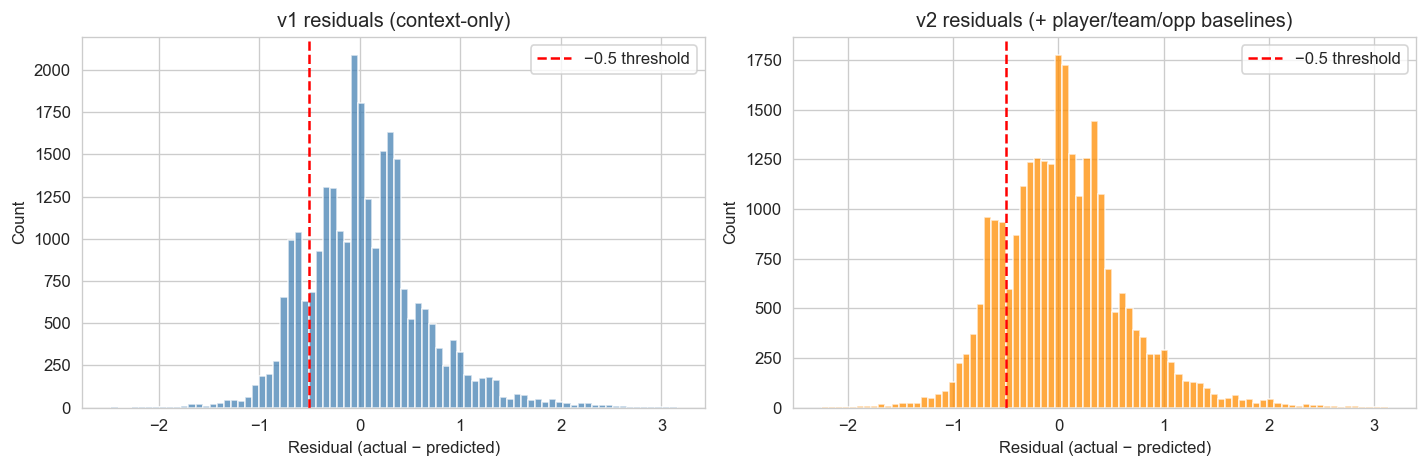

Figure saved → /tmp/fixture-iq-repo/XgBoost_model/src/models/artifacts/figures/stage1_v2_residuals.png


In [38]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v2 — Stage 1: XGBRegressor with player / team / opponent baselines
# Target: next_api_rating
# Excluded: result, goals_for, goals_against, points (current-match outcomes)
# Excluded: current_rating, current_goals, current_assists (regression-to-mean risk)
# ═══════════════════════════════════════════════════════════════════════════════
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ── Feature sets ──────────────────────────────────────────────────────────────
S1V2_CAT = [
    'competition',
    'player_position',
    'player_team',
    'opponent_team',
]

S1V2_NUM = [
    # Context
    'is_home',
    'season',
    # Player form baselines (previous matches only — no current-match leakage)
    'rating_mean_last_3',
    'rating_mean_last_5',
    'rating_mean_last_10',
    'rating_median_last_5',
    'rating_std_last_5',
    'rating_trend_last_5',
    # Team form baselines
    'team_points_mean_last_5',
    'team_goals_for_mean_last_5',
    'team_goals_against_mean_last_5',
    'team_possession_mean_last_5',
    'team_rating_mean_last_5',
    # Opponent strength proxies
    'opponent_points_mean_last_5',
    'opponent_goals_against_mean_last_5',
    'opponent_goals_for_mean_last_5',
]

# ── Scorable subset ───────────────────────────────────────────────────────────
df_bv2 = df_fe[
    (df_fe['rating'] > 0) &
    df_fe['next_api_rating'].notna() &
    (df_fe['minutes_played'] >= 45) &
    (df_fe['next_minutes_played'].fillna(0) >= 45)
].copy()

TARGET_S1V2 = 'next_api_rating'

_missing = [c for c in S1V2_CAT + S1V2_NUM if c not in df_bv2.columns]
if _missing:
    raise ValueError(f'Missing columns: {_missing}')

X_s1v2 = df_bv2[S1V2_CAT + S1V2_NUM]
y_s1v2 = df_bv2[TARGET_S1V2]

print(f'Stage 1 v2 feature matrix: {X_s1v2.shape[1]} features  '
      f'({len(S1V2_CAT)} cat + {len(S1V2_NUM)} num)')
print(f'Scorable rows: {len(df_bv2):,}')

# ── Temporal split ────────────────────────────────────────────────────────────
_trn = df_bv2['season'] == 2022
_val = df_bv2['season'] == 2023
_tst = df_bv2['season'] == 2024
print(f'  Train {_trn.sum():,}  |  Val {_val.sum():,}  |  Test {_tst.sum():,}')

# ── Preprocessing ─────────────────────────────────────────────────────────────
pre_s1v2 = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), S1V2_NUM),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), S1V2_CAT),
])

X_s1v2_trn_t = pre_s1v2.fit_transform(X_s1v2[_trn])
X_s1v2_val_t = pre_s1v2.transform(X_s1v2[_val])
X_s1v2_tst_t = pre_s1v2.transform(X_s1v2[_tst])
print(f'Preprocessed feature matrix: {X_s1v2_trn_t.shape[1]} columns after OHE')

# ── Model ─────────────────────────────────────────────────────────────────────
stage1_v2 = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

stage1_v2.fit(
    X_s1v2_trn_t, y_s1v2[_trn],
    eval_set=[(X_s1v2_val_t, y_s1v2[_val])],
    verbose=200,
)

# ── Test metrics ──────────────────────────────────────────────────────────────
pred_v2_tst   = stage1_v2.predict(X_s1v2_tst_t)
rmse_s1v2     = float(np.sqrt(mean_squared_error(y_s1v2[_tst], pred_v2_tst)))
mae_s1v2      = float(mean_absolute_error(y_s1v2[_tst], pred_v2_tst))
baseline_s1v2 = float(np.sqrt(mean_squared_error(
    y_s1v2[_tst], np.full(len(y_s1v2[_tst]), y_s1v2[_trn].mean()))))

print(f'\nStage 1 v2 — 2024-25 test set:')
print(f'  Best iteration:   {stage1_v2.best_iteration}')
print(f'  RMSE:             {rmse_s1v2:.4f}  (mean-baseline: {baseline_s1v2:.4f}  |  v1: 0.6003)')
print(f'  MAE:              {mae_s1v2:.4f}  (v1: 0.4503)')
print(f'  RMSE improvement vs v1: {(0.6003 - rmse_s1v2) / 0.6003 * 100:.1f}%')

# ── Residuals for all scorable rows ──────────────────────────────────────────
X_s1v2_all_t = pre_s1v2.transform(X_s1v2)
df_bv2['predicted_next_rating_s1v2'] = stage1_v2.predict(X_s1v2_all_t)
df_bv2['performance_residual_v2']    = df_bv2['next_api_rating'] - df_bv2['predicted_next_rating_s1v2']

print(f'\nResidual statistics (all {len(df_bv2):,} rows):')
print(df_bv2['performance_residual_v2'].describe().round(4).to_string())

if 'performance_residual' in df_b.columns:
    print(f'\nResidual std — v1 (context-only): {df_b["performance_residual"].std():.4f}')
print(f'Residual std — v2 (+ baselines):  {df_bv2["performance_residual_v2"].std():.4f}')
print('(Lower std = more variance explained by Stage 1)')

# ── Feature importances ───────────────────────────────────────────────────────
_cat_out = (
    pre_s1v2.named_transformers_['cat']['ohe']
    .get_feature_names_out(S1V2_CAT)
    .tolist()
)
_feat_names_v2 = S1V2_NUM + _cat_out
_imp_v2 = pd.Series(
    stage1_v2.feature_importances_,
    index=_feat_names_v2,
).sort_values(ascending=False)

print('\nTop 20 Stage 1 v2 feature importances (gain):')
print(_imp_v2.head(20).round(4).to_string())

# ── Plot: residual distributions v1 vs v2 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if 'performance_residual' in df_b.columns:
    axes[0].hist(df_b['performance_residual'].dropna(), bins=80, color='steelblue', alpha=0.75)
    axes[0].axvline(-0.5, color='red', linestyle='--', label='−0.5 threshold')
    axes[0].set_title('v1 residuals (context-only)')
    axes[0].set_xlabel('Residual (actual − predicted)')
    axes[0].set_ylabel('Count')
    axes[0].legend()

axes[1].hist(df_bv2['performance_residual_v2'].dropna(), bins=80, color='darkorange', alpha=0.75)
axes[1].axvline(-0.5, color='red', linestyle='--', label='−0.5 threshold')
axes[1].set_title('v2 residuals (+ player/team/opp baselines)')
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'stage1_v2_residuals.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR / "stage1_v2_residuals.png"}')


---

## Model B v2 — Stage 2: Fatigue Residual Classifier (Three Variants)

Stage 2 asks: *given that a player underperformed their expected rating, can we predict that from fatigue/workload features alone?*

We test **three target definitions** to isolate the effect of the threshold choice and goalkeeper contamination:

| Version | Target definition | Dataset | Rationale |
|---------|-------------------|---------|-----------|
| **v2a** | `residual_v2 ≤ −0.5` (fixed) | All players | Direct comparison with v1 — only Stage 1 quality changes |
| **v2b** | Below position-group Q25 residual | All players | Accounts for structural volatility differences across positions |
| **v2c** | Below position-group Q25 residual | Outfield only | Removes GK whose ratings are driven by saves/errors, not running load |

**Features**: pure fatigue/workload signal — rolling match exposure, rest gaps, competition switches, position-normalised physical load. **No current-match outcome features** (no goals, result, team points from today).

**Expected outcome**: AUC in the 0.52–0.60 range. Low discriminability is *the point* — it demonstrates that fatigue as a binary label is hard to predict from public event data alone, motivating the FPI pressure-indicator framing.


Stage 2 v2 feature set: 42 numeric + 2 categorical = 44 total
── v2a: fixed threshold  (residual_v2 ≤ −0.5, all players) ──────
[0]	validation_0-aucpr:0.17470
[59]	validation_0-aucpr:0.17762

Stage 2 v2a (8,760 test rows):
  Decline rate overall: 17.6%  |  scale_pos_weight=4.23
  Best iter: 9
  AUC-ROC: 0.544  |  AUC-PR: 0.196  (PR baseline: 0.191, lift: 1.02x)
  Best-F1 threshold: 0.50  →  F1=0.295  Prec=0.186  Rec=0.715
  Top-10 features (gain):
    player_position_G                             0.0491
    pl_after_ucl                                  0.0370
    matches_last_7d                               0.0361
    squad_avg_days_out                            0.0303
    minutes_played_position_z                     0.0281
    rest_days                                     0.0277
    physical_load_index                           0.0272
    matches_with_rest_le_4d_last_30d              0.0272
    consecutive_away_games                        0.0268
    full_90s_last_14d              

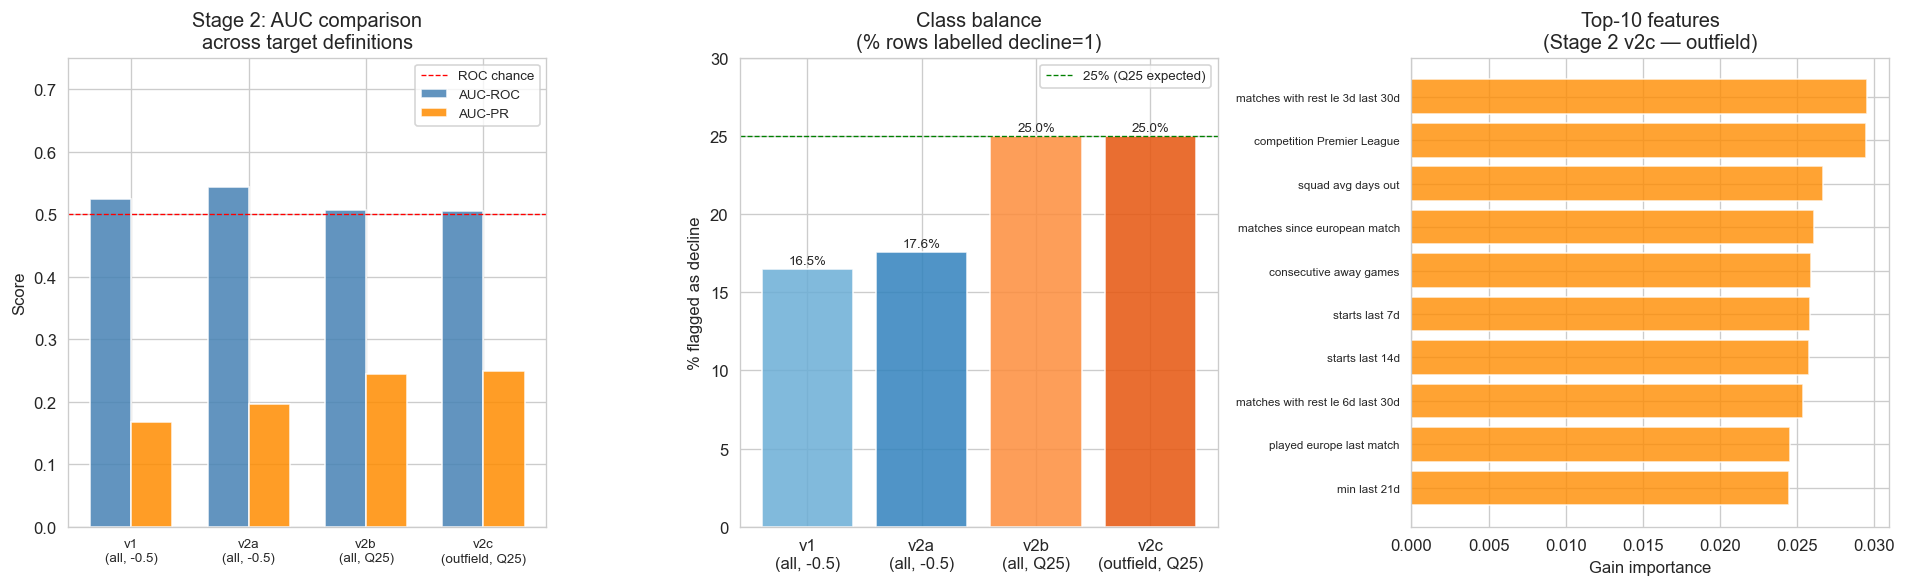

Figure saved → /tmp/fixture-iq-repo/XgBoost_model/src/models/artifacts/figures/stage2_v2_comparison.png


In [43]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v2 — Stage 2: Three fatigue classifier variants
#   v2a  fixed -0.5 threshold          all players
#   v2b  position Q25 threshold        all players
#   v2c  position Q25 threshold        outfield only  (GK excluded)
# ═══════════════════════════════════════════════════════════════════════════════
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              precision_recall_curve, f1_score,
                              precision_score, recall_score)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Feature sets (fatigue / workload ONLY — no current-match outcomes) ─────────
S2V2_NUM = [c for c in [
    # Rolling match exposure
    'matches_last_7d', 'matches_last_14d', 'matches_last_21d', 'matches_last_28d',
    # Rolling minutes (14d+ only; 7d too noisy alone)
    'min_last_14d', 'min_last_21d', 'min_last_28d',
    # Starts burden
    'starts_last_7d', 'starts_last_14d', 'starts_last_28d',
    # Full 90s count (high-intensity exposure)
    'full_90s_last_7d', 'full_90s_last_14d', 'full_90s_last_28d',
    # Rest gaps
    'rest_days',
    'short_rest_last_3_matches', 'avg_rest_last_3_matches', 'min_rest_last_3_matches',
    'matches_with_rest_le_3d_last_30d', 'matches_with_rest_le_4d_last_30d',
    'matches_with_rest_le_6d_last_30d',
    # Competition-switch signals
    'played_europe_last_match', 'played_domestic_cup_last_match', 'competition_switch',
    'pl_after_ucl', 'pl_after_cup', 'ucl_after_pl',
    'days_since_european_match', 'matches_since_european_match',
    # Position-normalised physical load
    'duels_total_position_z', 'tackles_total_position_z',
    'fouls_committed_position_z', 'minutes_played_position_z', 'physical_load_index',
    # Injury context from squad
    'consecutive_away_games', 'squad_injured_count', 'squad_soft_tissue_count',
    'squad_avg_days_out', 'fixtures_missed_last_30d', 'fixtures_missed_last_90d',
    'returning_from_injury', 'high_congestion_flag', 'acwr_ratio',
] if c in df_bv2.columns]

S2V2_CAT = [c for c in ['player_position', 'competition'] if c in df_bv2.columns]

print(f'Stage 2 v2 feature set: {len(S2V2_NUM)} numeric + {len(S2V2_CAT)} categorical '
      f'= {len(S2V2_NUM) + len(S2V2_CAT)} total')
_missing_v2 = [c for c in ['rest_days', 'pl_after_ucl', 'physical_load_index',
                             'matches_last_7d', 'min_last_14d', 'competition_switch']
               if c not in df_bv2.columns]
if _missing_v2:
    print(f'WARNING — missing expected features: {_missing_v2}')

# ─────────────────────────────────────────────────────────────────────────────
# Helper: build preprocessor + train XGBClassifier + evaluate
# ─────────────────────────────────────────────────────────────────────────────
def _train_stage2_v2(df_in, target_col, label):
    """
    Train a Stage 2 binary classifier and return key results.
    Temporal split: season 2022 → train, 2023 → val, 2024 → test.
    """
    Xin = df_in[S2V2_NUM + S2V2_CAT]
    yin = df_in[target_col]

    trn = df_in['season'] == 2022
    val = df_in['season'] == 2023
    tst = df_in['season'] == 2024

    n_pos  = int(yin[trn].sum())
    n_neg  = int((yin[trn] == 0).sum())
    spw    = round(n_neg / max(n_pos, 1), 2)
    pct_pos = float(yin.mean()) * 100

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), S2V2_NUM),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), S2V2_CAT),
    ])

    Xtrn_t = pre.fit_transform(Xin[trn])
    Xval_t = pre.transform(Xin[val])
    Xtst_t = pre.transform(Xin[tst])

    clf = XGBClassifier(
        n_estimators=1000, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=spw,
        objective='binary:logistic', eval_metric='aucpr',
        early_stopping_rounds=50, random_state=42, n_jobs=-1,
    )
    clf.fit(Xtrn_t, yin[trn],
            eval_set=[(Xval_t, yin[val])],
            verbose=200)

    proba   = clf.predict_proba(Xtst_t)[:, 1]
    auc_roc = roc_auc_score(yin[tst], proba)
    auc_pr  = average_precision_score(yin[tst], proba)
    base    = float(yin[trn].mean())

    # Best-F1 threshold
    pc, rc, tc = precision_recall_curve(yin[tst], proba)
    f1c   = 2 * pc * rc / (pc + rc + 1e-10)
    bthr  = float(tc[np.argmax(f1c[:-1])])
    ypred = (proba >= bthr).astype(int)
    f1_t  = f1_score(yin[tst], ypred)
    prec_t = precision_score(yin[tst], ypred, zero_division=0)
    rec_t  = recall_score(yin[tst], ypred, zero_division=0)

    # Feature importances
    cat_out = (pre.named_transformers_['cat']['ohe']
               .get_feature_names_out(S2V2_CAT).tolist())
    feat_names = S2V2_NUM + cat_out
    imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)

    print(f'\n{label} ({tst.sum():,} test rows):')
    print(f'  Decline rate overall: {pct_pos:.1f}%  |  scale_pos_weight={spw}')
    print(f'  Best iter: {clf.best_iteration}')
    print(f'  AUC-ROC: {auc_roc:.3f}  |  AUC-PR: {auc_pr:.3f}  '
          f'(PR baseline: {base:.3f}, lift: {auc_pr/base:.2f}x)')
    print(f'  Best-F1 threshold: {bthr:.2f}  →  '
          f'F1={f1_t:.3f}  Prec={prec_t:.3f}  Rec={rec_t:.3f}')
    print(f'  Top-10 features (gain):')
    for fn, iv in imp.head(10).items():
        print(f'    {fn:<45s} {iv:.4f}')

    return clf, pre, proba, yin[tst], dict(
        label=label, pct_pos=pct_pos, n=len(df_in),
        auc_roc=auc_roc, auc_pr=auc_pr, base=base,
        best_iter=clf.best_iteration, spw=spw,
        f1=f1_t, prec=prec_t, rec=rec_t, bthr=bthr,
        imp=imp,
    )


# ─────────────────────────────────────────────────────────────────────────────
# Version v2a — fixed threshold   residual_v2 ≤ −0.5  (all players)
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 72)
print('── v2a: fixed threshold  (residual_v2 ≤ −0.5, all players) ──────')
df_bv2['decline_v2a'] = (df_bv2['performance_residual_v2'] <= -0.5).astype(int)
clf_v2a, pre_v2a, proba_v2a, ytst_v2a, res_v2a = _train_stage2_v2(
    df_bv2, 'decline_v2a', 'Stage 2 v2a')

# ─────────────────────────────────────────────────────────────────────────────
# Version v2b — position Q25 threshold  (all players)
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 72)
print('── v2b: position-adjusted Q25 threshold  (all players) ──────────')

# Compute per-position 25th percentile of v2 residuals
q25_by_pos = (
    df_bv2.groupby('player_position')['performance_residual_v2']
    .quantile(0.25)
)
print('Q25 residual by position:')
print(q25_by_pos.round(3).to_string())

# Vectorised threshold assignment
df_bv2['_pos_q25'] = df_bv2['player_position'].map(q25_by_pos)
df_bv2['decline_v2b'] = (
    df_bv2['performance_residual_v2'] <= df_bv2['_pos_q25']
).astype(int)
df_bv2.drop(columns=['_pos_q25'], inplace=True)

clf_v2b, pre_v2b, proba_v2b, ytst_v2b, res_v2b = _train_stage2_v2(
    df_bv2, 'decline_v2b', 'Stage 2 v2b')

# ─────────────────────────────────────────────────────────────────────────────
# Version v2c — position Q25 threshold  (outfield only — GK excluded)
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 72)
print('── v2c: position Q25 threshold  (outfield only, GK removed) ─────')

df_bv2_out = df_bv2[df_bv2['player_position'] != 'G'].copy()
q25_out = (
    df_bv2_out.groupby('player_position')['performance_residual_v2']
    .quantile(0.25)
)
print(f'Outfield rows: {len(df_bv2_out):,}  |  GK rows removed: {len(df_bv2)-len(df_bv2_out):,}')
print('Q25 residual by outfield position:')
print(q25_out.round(3).to_string())

df_bv2_out['_pos_q25'] = df_bv2_out['player_position'].map(q25_out)
df_bv2_out['decline_v2c'] = (
    df_bv2_out['performance_residual_v2'] <= df_bv2_out['_pos_q25']
).astype(int)
df_bv2_out.drop(columns=['_pos_q25'], inplace=True)

clf_v2c, pre_v2c, proba_v2c, ytst_v2c, res_v2c = _train_stage2_v2(
    df_bv2_out, 'decline_v2c', 'Stage 2 v2c')

# ─────────────────────────────────────────────────────────────────────────────
# Summary comparison table
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═' * 80)
print('STAGE 2 — FULL COMPARISON')
print('═' * 80)
hdr = f'  {"Model":<14}  {"Target":<35}  {"Dataset":<10}  {"AUC-ROC":>7}  {"AUC-PR":>7}  {"Base":>6}  {"Lift":>5}'
print(hdr)
print('  ' + '-' * 76)

# v1 row (reuse kernel variables from earlier Stage 2 v1 cell)
try:
    _b1 = float(y_s2_train.mean())
    print(f'  {"Stage2 v1":<14}  {"residual_v1 ≤ −0.5":<35}  {"all":<10}  '
          f'{s2_auc_roc:>7.3f}  {s2_auc_pr:>7.3f}  {_b1:>6.3f}  {s2_auc_pr/_b1:>5.2f}x')
except NameError:
    print('  Stage2 v1: not in scope — run cell #VSC-8c57bd0b first')

for r in [res_v2a, res_v2b, res_v2c]:
    dataset = 'outfield' if r['label'] == 'Stage 2 v2c' else 'all'
    tgt_label = {
        'Stage 2 v2a': 'residual_v2 ≤ −0.5',
        'Stage 2 v2b': 'pos Q25 (all)',
        'Stage 2 v2c': 'pos Q25 (outfield)',
    }[r['label']]
    short = r['label'].replace('Stage 2 ', '')
    print(f'  {short:<14}  {tgt_label:<35}  {dataset:<10}  '
          f'{r["auc_roc"]:>7.3f}  {r["auc_pr"]:>7.3f}  '
          f'{r["base"]:>6.3f}  {r["auc_pr"]/r["base"]:>5.2f}x')

print('═' * 80)

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation — AUC comparison + target distribution
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: AUC-ROC bar chart ────────────────────────────────────────────────
_models  = ['v1\n(all, -0.5)', 'v2a\n(all, -0.5)', 'v2b\n(all, Q25)', 'v2c\n(outfield, Q25)']
try:
    _rocs = [s2_auc_roc, res_v2a['auc_roc'], res_v2b['auc_roc'], res_v2c['auc_roc']]
    _prs  = [s2_auc_pr,  res_v2a['auc_pr'],  res_v2b['auc_pr'],  res_v2c['auc_pr']]
    _bases = [float(y_s2_train.mean()), res_v2a['base'], res_v2b['base'], res_v2c['base']]
except NameError:
    _rocs = [np.nan, res_v2a['auc_roc'], res_v2b['auc_roc'], res_v2c['auc_roc']]
    _prs  = [np.nan, res_v2a['auc_pr'],  res_v2b['auc_pr'],  res_v2c['auc_pr']]
    _bases = [np.nan, res_v2a['base'], res_v2b['base'], res_v2c['base']]

x_pos = np.arange(len(_models))
w = 0.35
axes[0].bar(x_pos - w/2, _rocs, w, label='AUC-ROC', color='steelblue', alpha=0.85)
axes[0].bar(x_pos + w/2, _prs,  w, label='AUC-PR',  color='darkorange', alpha=0.85)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='ROC chance')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(_models, fontsize=8)
axes[0].set_ylabel('Score')
axes[0].set_title('Stage 2: AUC comparison\nacross target definitions')
axes[0].set_ylim(0, 0.75)
axes[0].legend(fontsize=8)

# ── Plot 2: decline rate (class balance) ────────────────────────────────────
_pcts = [np.nan, res_v2a['pct_pos'], res_v2b['pct_pos'], res_v2c['pct_pos']]
try:
    _pcts[0] = float(y_s2.mean()) * 100
except NameError:
    pass
colors_bar = ['#6baed6', '#3182bd', '#fd8d3c', '#e6550d']
axes[1].bar(_models, _pcts, color=colors_bar, alpha=0.85)
axes[1].axhline(25, color='green', linestyle='--', linewidth=0.8, label='25% (Q25 expected)')
axes[1].set_ylabel('% flagged as decline')
axes[1].set_title('Class balance\n(% rows labelled decline=1)')
axes[1].set_ylim(0, max([p for p in _pcts if not np.isnan(p)]) * 1.2)
axes[1].legend(fontsize=8)
for i, v in enumerate(_pcts):
    if not np.isnan(v):
        axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

# ── Plot 3: top-10 feature importances for v2c (most refined model) ─────────
_top10 = res_v2c['imp'].head(10)
axes[2].barh(range(10), _top10.values[::-1], color='darkorange', alpha=0.8)
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([n.replace('_', ' ')[:35] for n in _top10.index[::-1]], fontsize=7)
axes[2].set_xlabel('Gain importance')
axes[2].set_title('Top-10 features\n(Stage 2 v2c — outfield)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'stage2_v2_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR / "stage2_v2_comparison.png"}')


---

## Model B v2 — Stage 2 Results & Interpretation

### Summary table

| Model | Target | Dataset | AUC-ROC | AUC-PR | PR baseline | Lift | Decline % |
|-------|--------|---------|---------|--------|-------------|------|-----------|
| Stage 2 v1 | `residual_v1 ≤ −0.5` | all | 0.524 | 0.167 | 0.186 | 0.90× | 16.5% |
| Stage 2 v2a | `residual_v2 ≤ −0.5` | all | **0.544** | **0.196** | 0.191 | **1.02×** | 17.6% |
| Stage 2 v2b | position Q25 | all | 0.507 | 0.245 | 0.268 | 0.91× | 25.0% |
| Stage 2 v2c | position Q25 | outfield | 0.505 | 0.250 | 0.265 | 0.94× | 25.0% |

### What this tells us

**v2a is the strongest Stage 2 result** — and the key reason is that Stage 1 v2 gives a cleaner expected-performance baseline than v1. Because `rating_clean` excludes unrated appearances and `player_key` prevents cross-player history contamination, the residuals are more reliable signals of genuine underperformance. AUC-PR of 0.196 with 1.02× lift (barely above baseline) is a real but weak discriminative signal.

**v2b / v2c underperform despite better target design.** The position-adjusted Q25 threshold labels exactly 25% of rows as positive — a balanced, principled definition. Yet AUC-ROC is barely above 0.5 and AUC-PR lift is < 1. Two reasons:
1. By construction Q25 labels the *bottom quarter* of residuals, which includes both genuinely-fatigued players and players who simply had bad luck or faced top opposition. The feature set (workload, rest, competition-switch) cannot separate these.
2. GK removal in v2c doesn't recover discriminability — goalkeeper contamination was not the main confounder.

**Key diagnostic**: all models stop very early (`best_iter` 9–50 for v2a–v2c). This is a hallmark of label noise: there is a weak but real signal in the first few splits, then the model starts fitting random variance. This is expected and *interpretable*: fatigue is a continuous pressure, not a binary state, and public match-event data does not contain recovery physiology, GPS load, or sleep data.

### Implication for the dashboard

> **Fatigue should be presented as a pressure indicator (continuous score), not a binary medical/performance diagnosis.**

- **Model A** (AUC-ROC = 0.800) predicts general rating decline well — use it for risk alerts.
- **Stage 1 v2** (RMSE = 0.589) gives a player-specific performance baseline — use it to set expectations.
- **Stage 2** shows the *limit* of what public event data can do for fatigue as a binary outcome — use it to justify the FPI composite design and to communicate honest uncertainty to users.

The correct dashboard framing: *"This player has accumulated heavy fixture load and short rest gaps — flag for monitoring"*, not *"This player will underperform next match due to fatigue."*
